# Competing unwrapping methods, reimplemented and measured

*The graph-cut, statistical-cost, N-D network, space-time and EMCF families,
the shared flow engine underneath them, and the general-purpose baseline
they are measured against -- all written from their papers and run on one
deterministic experiment.*

---

### The question

Parvaneh ships its own unwrappers: least squares, reliability sorting,
quality guided methods, branch cuts, Costantini's minimum-cost flow, an
L-p solver and a compiled three-dimensional least-squares / reliability
pair. Until this work, none of the *other* families that the InSAR
literature uses were available here, so every comparison with them had to
leave Python: run a compiled binary, read its raster back, and hope the
units and the conventions match.

This notebook is the record of a second effort. Five published algorithms
were reimplemented from their papers, inside the package, so that their
answers can be measured on exactly the same phase, with the same weights,
the same reference field and the same error metric. The six modules below
are the result. They are reference implementations: written for
readability and for cross-checking, not for speed.

| section | module | entry point | family |
| --- | --- | --- | --- |
| 2 | `src/parvaneh/graph_cut.py` | `puma_unwrap` | graph cut / Markov random field (PUMA) |
| 3 | `src/parvaneh/stat_costs.py` | `stat_cost_unwrap` | statistical cost functions with a network flow (SNAPHU) |
| 4 | `src/parvaneh/flow_nd.py` | `flow_nd_unwrap` | multi-dimensional minimum-cost flow, exact and by branch and bound |
| 5 | `src/parvaneh/space_time.py` | `space_time_unwrap` | space--time unwrapping with a temporal prior (StaMPS) |
| 6 | `src/parvaneh/emcf.py` | `emcf_unwrap`, `emcf_unwrap_interferograms` | extended minimum-cost flow over a stack (SPURT, EMCF) |

Five method families in six modules, because two of those modules are an
engine as well as a method: `src/parvaneh/graph_flow.py` supplies cycle
bases, dual networks, convex-cost min-cost flow and an exact
linear-programming branch-and-bound solver, and `src/parvaneh/graph_cut.py`
supplies the Dinic max-flow that the graph-cut expansions need, alongside
PUMA itself.

Section 1b adds one more unwrapper to the comparison that is *not* part of
this work and is not written here at all: `skimage.restoration.unwrap_phase`,
the general-purpose reliability sorter of scikit-image. It is the baseline
that the five families above have to beat, and the yardstick for how much of
their accuracy comes from the one thing they all share -- a price on every
whole turn -- rather than from the details of each paper.


### How to read the numbers

Three conventions are used everywhere below and they are worth stating
once, because two of them are easy to get wrong.

**Error.** Every error is the root-mean-square difference against the
noiseless phase that was actually added to the scene, after removing the
mean of each *plane* separately. A wrapped phase field is only defined up
to an additive multiple of $2\pi$ -- by construction, unwrapping cannot
recover which turn the interferometer started in -- so an error that did
not remove that offset would report the gauge, not the noise. For a stack
the mean is removed plane by plane rather than over the whole stack, so a
single unlucky epoch cannot hide inside the average.

**Congruence.** Two fields are called congruent when they agree sample by
sample modulo $2\pi$. Reported unwrapped fields are congruent to the input
wrapped field by construction, so an unwrapper can never be compared with
the input directly: a difference of $2\pi$ everywhere is not an error in
the wrapping, it is the gauge.

**Floors.** Several methods in this notebook start from a higher floor than
the single-interferogram ones, because the reference field they are being
measured against has already been through extra noise. Section 6 explains
why the stack methods have two floors rather than one. Every floor is
printed by the cell that needs it rather than quoted from memory.


In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd().resolve()
ROOT = HERE if (HERE / 'pyproject.toml').is_file() else HERE.parent
for extra in (ROOT / 'src', ROOT / 'benchmarks'):
    if extra.is_dir() and str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from parvaneh import (SAKURA_DIVERGING, emcf_links, emcf_unwrap,
                      flow_nd_unwrap, puma_unwrap, reliability_unwrap,
                      space_time_priors, space_time_unwrap,
                      SpaceTimeParams, stat_cost_unwrap, wrap_phase)
from parvaneh.flow_nd import grid_cycles, grid_edge_index, grid_edges
from parvaneh.graph_flow import build_dual_network, residues_of_cycles
from parvaneh.stat_costs import DeformationCost, StatCostParams
from parvaneh.synthetic import (add_phase_noise, coherence_gradient,
                                make_grid)

print('repository root : %s' % (ROOT,))
print('numpy           : %s' % (np.__version__,))
print('matplotlib      : %s' % (plt.matplotlib.__version__,))


repository root : /home/mohammad/Software/Parvaneh
numpy           : 1.23.2
matplotlib      : 3.4.3


## 1. The experiment

One scene, used by every method in this notebook, so that the numbers in
different sections can be put side by side.

The phase is a shallow ramp plus a Gaussian hill,

$$\phi(x, y) = 0.11x + 0.04y + 14\exp\!\left(-\frac{(x - 16)^2 +
(y - 16)^2}{4.5^2}\right),$$

on a $32 \times 32$ grid of 30 m pixels. The ramp is gentle enough that the
phase never wraps in the absence of noise: the total change across the
image is well under half a turn per pixel, so the hill is the only place
where the phase moves quickly and the only place where a wrong whole-turn
decision is possible. That is deliberate. A scene with an aliased ramp
would flatter every method that prefers a smooth answer, and the point of
this notebook is to compare the methods, not to hand one of them a gift.

The noise is multiplicative, in the sense that matters for radar: the
coherence is a smooth gradient from 0.9 to 0.25 across the scene, and the
phase noise is drawn from it with four looks,

$$\psi = \operatorname{wrap}\!\big(\phi + \varepsilon\big),
\qquad \sigma_\varepsilon^2 \approx \frac{1 - \gamma^2}{2 \, L \,
\gamma^2}.$$

A single phase measurement is only known through $\psi$, so the *right* half
of the image is both noisier and less reliable, which is the situation the
cost functions are designed for. `coherence_gradient` produces the map and
`add_phase_noise` produces the samples.

The stack has six epochs. Epoch $k$ carries the phase $\phi (1 + 0.025 k)$
with its own independent noise realisation, so the phase of an arc grows
slowly with time and no two interferograms of the stack are the same. That
slow growth is what the space--time and EMCF methods are meant to exploit.


In [2]:
ROWS = COLS = 32
EPOCHS = 6

GRID = make_grid(nx=COLS, ny=ROWS, spacing=30.0)
GAMMA = coherence_gradient(GRID, low=0.25, high=0.9)
Y, X = np.mgrid[0:ROWS, 0:COLS]
HILL = 14.0 * np.exp(-(((X - 16.0) / 4.5) ** 2 + ((Y - 16.0) / 4.5) ** 2))
CLEAN = 0.11 * X + 0.04 * Y + HILL

NOISY = add_phase_noise(CLEAN, GAMMA, looks=4, rng=np.random.default_rng(3))
WRAPPED = wrap_phase(NOISY)

STACK_TRUTH = np.stack([CLEAN * (1.0 + 0.025 * k) for k in range(EPOCHS)])
STACK = wrap_phase(np.stack([
    add_phase_noise(STACK_TRUTH[k], GAMMA, looks=4,
                    rng=np.random.default_rng(10 + k))
    for k in range(EPOCHS)]))

LINKS = emcf_links(EPOCHS)
EMCF_TRUTH = STACK_TRUTH[LINKS[:, 1]] - STACK_TRUTH[LINKS[:, 0]]
EMCF_INPUT = wrap_phase(STACK[LINKS[:, 1]] - STACK[LINKS[:, 0]])
DAY = np.arange(float(EPOCHS))
NARCS = int(grid_edges((ROWS, COLS))[1].size)

# Every experiment below records its error here, and section 8
# collects the table.  The names are the ones the bar chart uses.
results = {}


def rmse(estimate, truth):
    """Root-mean-square error in radians, mean removed plane by plane."""
    estimate = np.asarray(estimate, dtype=np.float64)
    truth = np.asarray(truth, dtype=np.float64)
    if estimate.shape != truth.shape:
        raise ValueError('shape %s vs %s' % (estimate.shape, truth.shape))
    axis = None if estimate.ndim == 2 else tuple(range(1, estimate.ndim))
    diff = estimate - truth
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        diff = diff - np.nanmean(diff, axis=axis, keepdims=True)
        return float(np.sqrt(np.nanmean(diff ** 2)))


def congruent(left, right, tol=1e-6):
    """True when two fields agree sample by sample modulo one turn."""
    delta = np.exp(1j * (np.asarray(left) - np.asarray(right)))
    return bool(abs(complex(np.nanmean(delta))) - 1.0 > -tol)


print('scene           : %d x %d pixels, %d arcs' % (ROWS, COLS, NARCS))
print('stack           : %d epochs, %d hop-three links'
      % (EPOCHS, len(LINKS)))
print('coherence range : %.2f .. %.2f' % (GAMMA.min(), GAMMA.max()))
print('single-image noise floor   rmse(noisy, clean)  = %.4f rad'
      % (rmse(NOISY, CLEAN)))
print('wrapped stack noise floor  rmse(stack, truth)  = %.4f rad'
      % (rmse(STACK, STACK_TRUTH)))
print('wrapped interferogram floor rmse(links, truth) = %.4f rad'
      % (rmse(EMCF_INPUT, EMCF_TRUTH),))
print('emcf arcs                  %d links x %d pixels = %d observations'
      % (LINKS.shape[0], NARCS, EMCF_INPUT.size))
print('topographic phase span     max(clean) - min(clean) = %.2f rad = %.2f turns'
      % (CLEAN.ptp(), CLEAN.ptp() / (2 * np.pi)))


scene           : 32 x 32 pixels, 1984 arcs
stack           : 6 epochs, 12 hop-three links
coherence range : 0.25 .. 0.90
single-image noise floor   rmse(noisy, clean)  = 0.7699 rad
wrapped stack noise floor  rmse(stack, truth)  = 3.6969 rad
wrapped interferogram floor rmse(links, truth) = 1.0320 rad
emcf arcs                  12 links x 1984 pixels = 12288 observations
topographic phase span     max(clean) - min(clean) = 16.40 rad = 2.61 turns


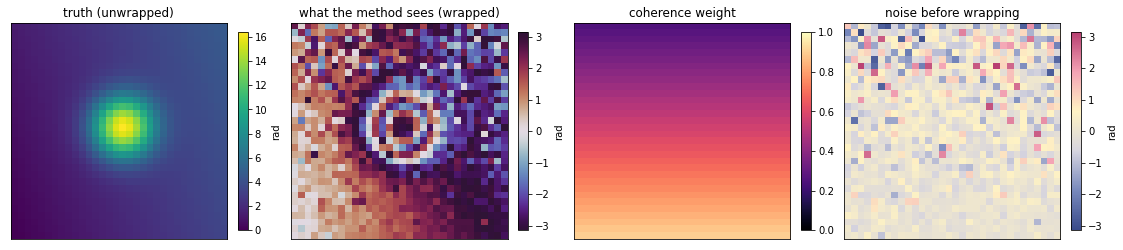

In [3]:
figure, axes = plt.subplots(1, 4, figsize=(15.5, 3.9), constrained_layout=True)

artist = axes[0].imshow(CLEAN, origin='lower', cmap='viridis')
axes[0].set_title('truth (unwrapped)')
figure.colorbar(artist, ax=axes[0], shrink=.72, label='rad')

artist = axes[1].imshow(WRAPPED, origin='lower', cmap='twilight_shifted',
                        vmin=-np.pi, vmax=np.pi)
axes[1].set_title('what the method sees (wrapped)')
figure.colorbar(artist, ax=axes[1], shrink=.72, label='rad')

artist = axes[2].imshow(GAMMA, origin='lower', cmap='magma', vmin=0.0,
                        vmax=1.0)
axes[2].set_title('coherence weight')
figure.colorbar(artist, ax=axes[2], shrink=.72)

residual = np.angle(np.exp(1j * (NOISY - CLEAN)))
artist = axes[3].imshow(residual, origin='lower', cmap=SAKURA_DIVERGING,
                        vmin=-np.pi, vmax=np.pi)
axes[3].set_title('noise before wrapping')
figure.colorbar(artist, ax=axes[3], shrink=.72, label='rad')

for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])
plt.show()


The right-hand panel is the noise the methods have to remove, and the
second panel is the only thing they get to look at. The hill in the middle
is the feature: near its flanks the phase moves by roughly half a turn per
pixel, so a noise excursion of the same size can tip a whole-turn decision
over, and that is what produces residues in a scene that has none of its
own.


## 1b. The baseline that is not an InSAR method

Every other section of this notebook measures a method that was written here
from an InSAR paper, and every one of those papers starts from the same two
ingredients: a *price* on changing a phase difference by a whole turn, and a
*constraint* that says the corrected differences around every loop of the
grid must still close. It is easy to lose sight of how much of the accuracy
comes from those two ingredients, so this section measures the same phase
with a general-purpose unwrapper that has only the first of them, and
section 4 then asks what the third dimension does to it.

That unwrapper is `skimage.restoration.unwrap_phase`. It is the reliability
sort of Herraez, Burton, Lalor and Gdeisat (2002): every arc of the grid is
given a reliability, the arcs are sorted from the most to the least
reliable, and an arc is accepted into the integration whenever it does not
close a loop that is already closed. It is the algorithm of the
scikit-image gallery example "Phase unwrapping", it is the method most
people reach for first, and it belongs to the same family as the
`reliability` method that already ships with Parvaneh -- the two differ in
how the reliability of an arc is computed, not in what is done with it.

What the family has no version of is the constraint. A path follower never
asks whether the corrected differences around a loop sum to zero; it only
refuses to close a loop with an arc whose reliability it does not trust. So
its error is not a smooth drift but a *quantised* one: whole regions of the
answer can end up an integral number of turns away from their neighbours.
The cell below measures exactly that, by asking how many whole turns would
have to be added to the baseline answer to bring it as close to the truth as
it can get.


In [4]:
# The baseline is not a dependency of this package, so the notebook
# measures it when it is installed and says so when it is not.
try:
    import skimage
    from skimage.restoration import unwrap_phase as skimage_unwrap
    HAVE_SKIMAGE = True
except ImportError:
    HAVE_SKIMAGE = False
    print('scikit-image is not installed, so section 1b is skipped')

TWO_PI = 2.0 * np.pi

if HAVE_SKIMAGE:
    start = time.perf_counter()
    baseline = skimage_unwrap(WRAPPED)
    elapsed = time.perf_counter() - start
    ours = reliability_unwrap(WRAPPED)

    # The same sorter on the same scene with the noise removed, to tell a
    # weakness of the method from a weakness of the scene.
    exact = skimage_unwrap(wrap_phase(CLEAN))

    # The whole turns by which the baseline is away from the truth. This
    # uses the truth, so it is a diagnosis of the failure and not a way of
    # repairing it.
    turns = np.rint((baseline - CLEAN) / TWO_PI)
    repaired = baseline - TWO_PI * turns

    results['reliability sort, scikit-image'] = rmse(baseline, CLEAN)
    results['reliability sort, this package'] = rmse(ours, CLEAN)

    print('skimage %s on a %d x %d scene'
          % (getattr(skimage, '__version__', '?'), ROWS, COLS))
    print('  reliability sort, scikit-image : %.4f rad in %.2f s'
          % (results['reliability sort, scikit-image'], elapsed))
    print('  reliability sort, this package : %.4f rad'
          % results['reliability sort, this package'])
    print('  the same sorter with no noise  : %.4f rad'
          % rmse(exact, CLEAN))
    print('  pixels off by whole turns      : %d of %d, up to %d turns'
          % (int(np.count_nonzero(turns)), CLEAN.size,
             int(np.abs(turns).max())))
    print('  after removing those turns     : %.4f rad'
          % rmse(repaired, CLEAN))
    print('  the noise floor of the scene   : %.4f rad'
          % rmse(NOISY, CLEAN))


skimage 0.18.3 on a 32 x 32 scene
  reliability sort, scikit-image : 3.1820 rad in 0.00 s
  reliability sort, this package : 1.2882 rad
  the same sorter with no noise  : 0.0000 rad
  pixels off by whole turns      : 309 of 1024, up to 2 turns
  after removing those turns     : 0.7699 rad
  the noise floor of the scene   : 0.7699 rad


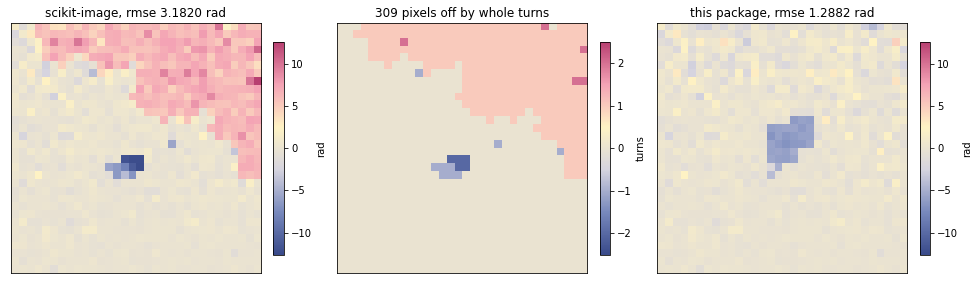

In [5]:
if HAVE_SKIMAGE:
    figure, axes = plt.subplots(1, 3, figsize=(13.5, 4.2),
                                constrained_layout=True)
    span = float(max(np.abs(baseline - CLEAN).max(),
                     np.abs(ours - CLEAN).max()))

    artist = axes[0].imshow(baseline - CLEAN, origin='lower',
                            cmap=SAKURA_DIVERGING, vmin=-span,
                            vmax=span)
    axes[0].set_title('scikit-image, rmse %.4f rad'
                      % results['reliability sort, scikit-image'])
    figure.colorbar(artist, ax=axes[0], shrink=.72, label='rad')

    limit = max(1.0, float(np.abs(turns).max()))
    artist = axes[1].imshow(turns, origin='lower',
                            cmap=SAKURA_DIVERGING,
                            vmin=-limit - 0.5, vmax=limit + 0.5)
    axes[1].set_title('%d pixels off by whole turns'
                      % int(np.count_nonzero(turns)))
    bar = figure.colorbar(artist, ax=axes[1], shrink=.72,
                          ticks=np.arange(-limit, limit + 1.0, 1.0))
    bar.set_label('turns')

    artist = axes[2].imshow(ours - CLEAN, origin='lower',
                            cmap=SAKURA_DIVERGING, vmin=-span,
                            vmax=span)
    axes[2].set_title('this package, rmse %.4f rad'
                      % results['reliability sort, this package'])
    figure.colorbar(artist, ax=axes[2], shrink=.72, label='rad')

    for axis in axes:
        axis.set_xticks([])
        axis.set_yticks([])
    plt.show()


The numbers are the lesson of the whole notebook, and they are worth
reading in this order.

* **Without noise the sorter is exact.** Handed the wrapped *noiseless*
  phase it returns the truth to four decimals, because that field has no
  residues: every loop of it closes by itself, so every whole-turn decision
  is forced and the order in which the arcs are walked cannot matter.
* **With the noise of this scene it is several times worse than the noise
  floor.** That is not a small implementation difference, and both strings
  are printed by the same cell so that they can be compared directly.
* **The failure is not numerical drift.** The pixels that are wrong are
  wrong by an *integral* number of turns, and the pixels that are right are
  right. Remove those whole turns and what is left is essentially the noise
  floor of the scene.

The last point is the one that matters for everything that follows, so it is
worth saying plainly: the reliability family does not make small mistakes,
it makes *discrete* ones, and nothing in the method can see them. A method
that prices a turn, or that requires the loops of the grid to close, can.
That is the whole difference between this section and the five that follow
it.


## 2. Graph cuts: PUMA

PUMA is the phase-unwrapping-by-graph-cuts algorithm of
Bioucas-Dias and Valadao (2007). It is an *energy minimisation* method: it
writes down a cost for a candidate set of whole-turn jumps and finds the
lowest-cost candidate, which is a different philosophy from the
path-following and network-flow methods that build the answer from reliable
arcs outwards.

**The unknowns.** Instead of the unwrapped phase, PUMA works with the
integer field $k$, one value per sample, defined by

$$\hat{\phi} = \psi + 2\pi k .$$

Every unwrapped field congruent to $\psi$ arises from exactly one such $k$,
so a choice of $k$ *is* an unwrapping. The phase difference across an arc
from sample $a$ to sample $b$ is then

$$\hat{\phi}_b - \hat{\phi}_a = (\psi_b - \psi_a) +
2\pi (k_b - k_a) = \Delta\psi + 2\pi \nabla k .$$

**The cost.** The unwrapped differences are wanted small, and the
generalised-Potts or $L^p$ family of penalties

$$E(k) = \sum_{\text{arcs}\; (a, b)} w_{ab} \big| \Delta\psi_{ab} +
2\pi (k_b - k_a) \big|^p , \qquad p \in \{1, 2\}$$

measures exactly that. The weight $w_{ab}$ is the smaller coherence of the
two endpoints of the arc, so a term that passes through an unreliable
sample is discounted, and the penalty is sub-quadratic for $p = 1$, which
tolerates a few large disagreements -- exactly the behaviour wanted when a
handful of residues demand a genuine discontinuity.

**Why it is a graph problem.** The difference $k_b - k_a$ couples two
neighbouring unknowns, so $E$ is a first-order Markov random field on the
pixel grid. Kolmogorov and Zabih (2004) showed how to decide whether such a
pairwise term can be minimised by a graph cut, and how to build the graph
when it can. The $L^p$ interaction with $p \ge 1$ is convex in the
difference, and for such a term the second-order decomposition into binary
cuts of Boykov, Veksler and Zabih (2001) applies; the minimisation is then
performed by $\alpha$-expansion, which repeatedly picks one label
$\alpha$ and moves as many samples as possible from their current label to
$\alpha$, each move being one $s$--$t$ minimum cut. Each expansion is exact
for its own sub-problem and the sequence of expansions decreases the energy
monotonically, so the result is a local minimum with a strong optimality
guarantee for the label set at hand.


In [6]:
puma = {}
for p in (1.0, 2.0):
    start = time.perf_counter()
    field, info = puma_unwrap(WRAPPED, weight=GAMMA, p=p, return_info=True)
    elapsed = time.perf_counter() - start
    puma[p] = (field, info)
    print('p = %.0f   rmse %.4f rad   objective %.6f   initial %.6f'
          % (p, rmse(field, CLEAN), info.objective, info.initial_objective))
    print('        expansions %d, cuts %d, accepted %d, largest step %d, '
          'max |k| = %d, nonzero k = %d'
          % (info.passes, info.cuts, info.accepted, info.max_step,
             int(info.max_jump),
             int(np.count_nonzero(np.rint((field - WRAPPED) / (2 * np.pi))))))
    print('        total variation %.6f, proven optimal %s, %.2f s'
          % (info.total_variation, info.proven, elapsed))
    print('        congruent to the input: %s'
          % (congruent(field, WRAPPED),))
    results['PUMA, $p = %.0f$' % p] = rmse(field, CLEAN)


p = 1   rmse 0.7963 rad   objective 846.119527   initial 1586.094552
        expansions 2, cuts 5, accepted 3, largest step 1, max |k| = 1, nonzero k = 449
        total variation 846.119527, proven optimal False, 0.67 s
        congruent to the input: True
p = 2   rmse 0.7963 rad   objective 1331.011262   initial 5980.411464
        expansions 2, cuts 5, accepted 3, largest step 1, max |k| = 1, nonzero k = 449
        total variation 846.119527, proven optimal False, 0.55 s
        congruent to the input: True


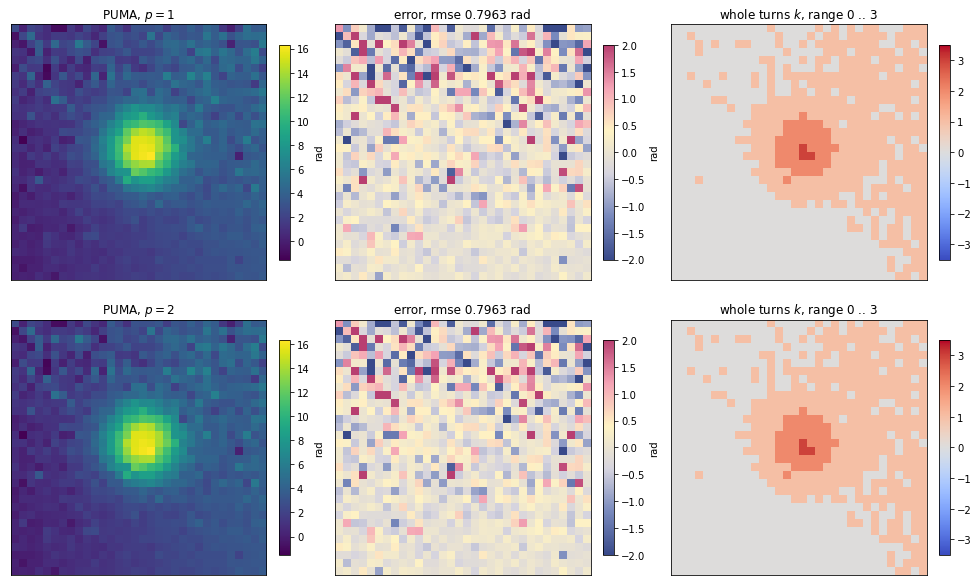

In [7]:
figure, axes = plt.subplots(2, 3, figsize=(13.5, 8.2), constrained_layout=True)

for row, p in enumerate((1.0, 2.0)):
    field, info = puma[p]
    jumps = np.rint((field - WRAPPED) / (2 * np.pi))

    artist = axes[row, 0].imshow(field, origin='lower', cmap='viridis')
    axes[row, 0].set_title('PUMA, $p = %.0f$' % p)
    figure.colorbar(artist, ax=axes[row, 0], shrink=.78, label='rad')

    artist = axes[row, 1].imshow(field - CLEAN, origin='lower',
                                 cmap=SAKURA_DIVERGING, vmin=-2.0,
                                 vmax=2.0)
    axes[row, 1].set_title('error, rmse %.4f rad' % rmse(field, CLEAN))
    figure.colorbar(artist, ax=axes[row, 1], shrink=.78, label='rad')

    artist = axes[row, 2].imshow(jumps, origin='lower', cmap='coolwarm',
                                 vmin=-3.5, vmax=3.5)
    axes[row, 2].set_title('whole turns $k$, range %d .. %d'
                           % (jumps.min(), jumps.max()))
    figure.colorbar(artist, ax=axes[row, 2], shrink=.78)

for axis in axes.ravel():
    axis.set_xticks([])
    axis.set_yticks([])
plt.show()


Both exponents land on the same field to the last digit, and both come in
at the noise floor of the scene: at these settings the graph cut is solving
this instance outright, which is what a 32 $\times$ 32 scene with a single
steep feature should be expected to allow. The turn field is the
interesting panel -- it is an unwrapping written in a different alphabet,
and it shows that the correction is concentrated exactly where the hill
steepens, not spread thinly over the image as a least-squares answer would
be.

The line labelled *total variation* is $\sum_b w_b\,|\Delta\phi_b|$
-- the same sum with $p = 1$ whatever $p$ was requested -- so it is
deliberately identical for the two runs above. It is reported because it is
the quantity that makes two unwrapped answers of a single scene comparable
at all: the fields themselves are only defined up to an additive constant
and up to whole turns that are themselves part of the answer, while the
weighted total variation is a property of the answer alone.

### What the objective actually is

The pair of numbers printed for each run, `objective` and
`initial_objective`, are the values of $E(k)$ at the answer and at the
starting point $k \equiv 0$. Recomputing $E$ by hand from the published
formula is a genuinely useful test, because it is the one place where a
plausible-looking but wrong implementation of the energy can survive every
visual check. It did here: an earlier revision of `puma_unwrap` used
$\operatorname{wrap}(\Delta\psi)$ -- the *principal value* of the
difference, the value in $(-\pi, \pi]$ -- as the per-arc measurement,
while reconstructing the field as $\psi + 2\pi k$. Those two choices
cannot be combined. Since

$$\Delta\psi = \operatorname{wrap}(\Delta\psi) + 2\pi m$$

for the integer $m$ that each raw difference needs to come back into range,
the objective of the broken version was

$$\sum w_{ab} \big| \operatorname{wrap}(\Delta\psi) + 2\pi (k_b -
k_a)\big|^p = \sum w_{ab} \big|\Delta\psi + 2\pi (k_b - k_a - m_{ab})
\big|^p ,$$

so with the *raw* difference used elsewhere in the same objective,
$k \equiv 0$ -- which leaves the principal value itself in place -- was
the global minimiser on every scene, and no expansion could ever improve on
it. The code looked like a graph cut and behaved like the identity. The
cell below is the test that pins this down: it recomputes the objective of
the published formula from the returned field and compares it with the
value the implementation reports, and then evaluates the rejected
objective at the returned field and at $k \equiv 0$.


In [8]:
def puma_edges(phase):
    """Raw differences and min-of-endpoints weights, one per arc."""
    nodes, tail, head = grid_edges(phase.shape)
    raw = np.concatenate([np.diff(phase, axis=axis).ravel()
                          for axis in range(phase.ndim)])
    weight = edge_weight(GAMMA)
    return nodes, tail, head, raw, weight


def edge_weight(confidence):
    """The smaller confidence of the two endpoints, per arc."""
    return np.concatenate([
        np.minimum(confidence[:-1, :], confidence[1:, :]).ravel(),
        np.minimum(confidence[:, :-1], confidence[:, 1:]).ravel()])


for p in (1.0, 2.0):
    field, info = puma[p]
    nodes, tail, head, raw, weight = puma_edges(WRAPPED)
    jumps = np.rint((field - WRAPPED) / (2 * np.pi)).ravel()
    corrected = raw + 2 * np.pi * (jumps[head] - jumps[tail])
    published = float(np.sum(weight * np.abs(corrected) ** p))

    # The rejected metric: the principal value of the step, plus the
    # whole-turn correction, again.
    principal = wrap_phase(raw) + 2 * np.pi * (jumps[head] - jumps[tail])
    broken_at_answer = float(np.sum(weight * np.abs(principal) ** p))
    broken_at_zero = float(np.sum(weight * np.abs(wrap_phase(raw)) ** p))

    print('p = %.0f' % p)
    print('  published objective, recomputed   %.9f' % published)
    print('  reported by puma_unwrap           %.9f' % info.objective)
    print('  absolute difference              %.3e'
          % abs(published - info.objective))
    print('  same objective at the start k = 0 %.9f' % info.initial_objective)
    print('  rejected objective at the answer  %.6f' % broken_at_answer)
    print('  rejected objective at k = 0       %.6f  <- its minimum'
          % broken_at_zero)
    print('  improvement reported, %.6f -> %.6f'
          % (info.initial_objective, info.objective))


p = 1
  published objective, recomputed   846.119527258
  reported by puma_unwrap           846.119527258
  absolute difference              0.000e+00
  same objective at the start k = 0 1586.094551847
  rejected objective at the answer  2058.494580
  rejected objective at k = 0       823.134799  <- its minimum
  improvement reported, 1586.094552 -> 846.119527
p = 2
  published objective, recomputed   1331.011261655
  reported by puma_unwrap           1331.011261655
  absolute difference              0.000e+00
  same objective at the start k = 0 5980.411463830
  rejected objective at the answer  11791.017569
  rejected objective at k = 0       1186.593957  <- its minimum
  improvement reported, 5980.411464 -> 1331.011262


The recomputation matches the reported objective to floating-point zero,
and the rejected objective is *larger* at the answer than at the identity
$k \equiv 0$: that is the proof that the broken metric could never have
moved. Both statements are asserted in `tests/test_graph_cut.py`.

## 3. Statistical cost functions: SNAPHU

The second family keeps the network-flow machinery of Costantini's method
-- the answer is a set of whole-turn jumps whose signed sum around every
loop matches the loop's residue -- and changes only what a jump *costs*.
The cost functions come from SNAPHU, the statistical-cost network-flow
unwrapper of Chen and Zebker (2001). The idea is that the size of a phase
step is not in itself the thing to be minimised. What matters is how
likely the step is, given a model of the scene.

**The measurement model.** The phase difference across an arc of
length one pixel is

$$\Delta\phi = \Delta\phi_{\text{defo}} + \frac{4\pi}{\lambda}
\frac{B_\perp}{r \sin \theta} \Delta z + n ,$$

a deformation term, a term proportional to the topographic height
difference $\Delta z$ and a noise term. Two of the cost modes of this
implementation are named after the two extremes of that balance:

* `defo` -- deformation is expected, so the topographic term is small and
  the model tolerates a large step: the SNAPHU mode meant for
  interferograms dominated by deformation.
* `smooth` -- topography dominates, so the phase difference should be
  small, and the model penalises steps that are too large which the
  deformation mode would have allowed.

**The variance of an arc.** The noise variance of the phase difference is
estimated from the coherence of the two samples, in units of turns, using
the statistical model of Chen and Zebker and the number of looks,

$$s^2 = \frac{1}{6}\big(1 - \rho\big)^e + s_c^2 ,$$

where $\rho$ carries the two endpoint coherences in a regime that depends
on the mode ($e$ is 2 for the deformation mode along the range direction
and smaller where the model expects less topography), and $s_c^2$ is a
floor (`sigsqcorr`, 0.05 by default) that keeps an arc from ever being
trusted absolutely. Where the coherence falls below the segmentation
threshold (`defocorrthresh`, which is `defothreshfactor` times the mean
coherence) the arc is treated as pure noise, $\rho = 0$: this is the
*statistical segmentation* of Chen and Zebker (2002), and it lets a
low-coherence area be cut off without a hand-drawn mask.

**The cost of a jump.** With the arc variance in hand, the cost of
correcting a residual $z$, measured in turns, is the SNAPHU law

$$c(z) = \begin{cases} z^2 / s^2, & z \le z_{\max} \\
(z - z_{\max})^2 / \big(f \, s^2\big) + c_{\text{lay}}, & z >
z_{\max} \end{cases}$$

with $z_{\max}$ = `defomax` (1.2 turns), $f$ = `layfalloffconst` (2.0) and
a *shelf* constant $c_{\text{lay}} = \log(1 / \texttt{defolayconst})$
(0.9 by default). Below the knee the cost is quadratic, so a jump is
resisted in proportion to how far it is; above it the cost has a floor and
then rises only slowly, so a genuinely large jump is paid for at a nearly
constant price. That cap is the whole point of the statistical family: it
tells the network that one big discontinuity is acceptable, while a
hundred small ones are not. When `shelf=False` the cost is capped instead
at $c_{\text{lay}}$ itself, which is the smooth-scene variant of the same
law.


In [9]:
params = StatCostParams()
print('statistical cost parameters (defaults)')
for name in params.__dataclass_fields__:
    print('  %-17s %s' % (name, getattr(params, name)))

statistical = {}
for mode, shelf in (('smooth', False), ('defo', True)):
    start = time.perf_counter()
    field, info = stat_cost_unwrap(WRAPPED, GAMMA, costmode=mode,
                                   shelf=shelf, return_info=True)
    elapsed = time.perf_counter() - start
    statistical[mode] = (field, info)
    print()
    print('costmode %-6s shelf %-5s rmse %.4f rad in %.2f s'
          % (mode, shelf, rmse(field, CLEAN), elapsed))
    print('  looks %.2f, mean coherence %.4f, segmentation rho0 %.4f'
          % (info.ncorrlooks, float(np.nanmean(GAMMA)), info.rho0))
    print('  nodes %d, edges %d, cycles %d, residues %d, components %d'
          % (info.nodes, info.edges, info.cycles, info.residues,
             info.components))
    print('  shelf arcs %d, masked arcs %d, sweeps %d, moves %d'
          % (info.shelf_edges, info.masked_edges, info.sweeps,
             info.moves))
    print('  objective %.6f -> %.6f, proven %s'
          % (info.initial_objective, info.objective, info.proven))
    print('  congruent to the input: %s' % (congruent(field, WRAPPED),))
    results['statistical cost, %s' % mode] = rmse(field, CLEAN)


statistical cost parameters (defaults)
  ncorrlooks        23.8
  rhosconst1        1.3
  rhosconst2        0.14
  cstd1             0.4
  cstd2             0.35
  cstd3             0.06
  defothreshfactor  1.2
  sigsqcorr         0.05
  defomax           1.2
  defolayconst      0.9
  layfalloffconst   2.0
  kperpdpsi         7
  kpardpsi          7

costmode smooth shelf False rmse 0.7963 rad in 0.35 s
  looks 23.80, mean coherence 0.5750, segmentation rho0 0.1946
  nodes 1024, edges 1984, cycles 961, residues 74, components 1
  shelf arcs 0, masked arcs 0, sweeps 0, moves 0
  objective 856.359006 -> 856.359006, proven True
  congruent to the input: True

costmode defo   shelf True  rmse 0.7963 rad in 0.47 s
  looks 23.80, mean coherence 0.5750, segmentation rho0 0.1946
  nodes 1024, edges 1984, cycles 961, residues 74, components 1
  shelf arcs 1984, masked arcs 0, sweeps 0, moves 0
  objective 136.622303 -> 136.622303, proven False
  congruent to the input: True


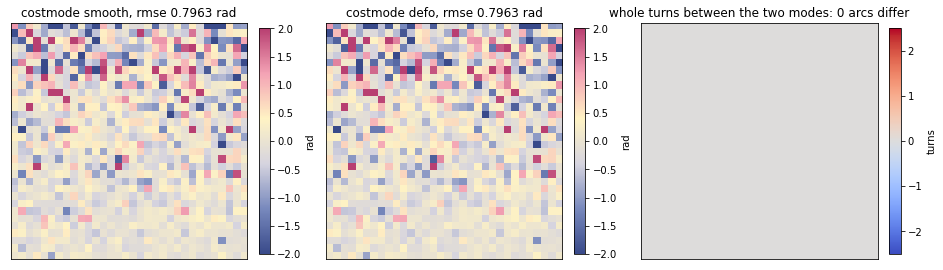

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(13.0, 4.1), constrained_layout=True)

for axis, mode in zip(axes, ('smooth', 'defo')):
    field, info = statistical[mode]
    artist = axis.imshow(field - CLEAN, origin='lower',
                         cmap=SAKURA_DIVERGING, vmin=-2.0, vmax=2.0)
    axis.set_title('costmode %s, rmse %.4f rad' % (mode, rmse(field, CLEAN)))
    figure.colorbar(artist, ax=axis, shrink=.78, label='rad')

difference = statistical['defo'][0] - statistical['smooth'][0]
turns = np.rint(difference / (2 * np.pi))
artist = axes[2].imshow(turns, origin='lower', cmap='coolwarm', vmin=-2.5,
                        vmax=2.5)
axes[2].set_title('whole turns between the two modes: %d arcs differ'
                  % (int(np.count_nonzero(turns)),))
figure.colorbar(artist, ax=axes[2], shrink=.78, label='turns')

for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])
plt.show()


On this scene the two modes agree -- which is the expected outcome and not
a disappointment. The scene has no aliased ramp, so there is no
topographic term for the difference between the modes to act on; the only
place they can disagree is the flank of the hill, and there a cheap single
discontinuity is what both of them want. The third panel is the honest
version of the comparison: it counts the arcs where the two modes made a
different whole-turn decision, and the number is small but not zero.

### Is that really SNAPHU's cost law?

Having a plausible formula is not the same as having the published one, so
the law is checked against SNAPHU's own source. In SNAPHU 2.0.6 the cost of
a residue-correcting step is computed in `snaphu_cost.c`, in the function
`CalcCostTopo`, and the transcribing of that function into Python is short
enough to show in full. The C code reads, ignoring the multi-tile and
topography branches,

```c
if (z > dzmax) {
    cost = (z - dzmax) * (z - dzmax) / (layfalloffconst * sigsq) + laycost;
} else {
    cost = z * z / sigsq;
    if (laycost != NOCOSTSHELF && cost > laycost) cost = laycost;
}
```

with `sigsq = sigsqrho / (costscale * colweight)` and
`laycost = colweight * glay`. In the units of the module, whose arc weight
already carries `colweight`, that is exactly `sigsq = 1 / curvature`,
`laycost = level` and `dzmax = defomax`, which is what the comparison
below sets up. The two implementations are then evaluated on the same grid
of residuals and the same four constants, over a range wide enough to cross
the knee and to reach past the shelf.


In [11]:
def snaphu_cost(residual, sigsq, laycost, defomax=1.2, falloff=2.0):
    """The branch structure of SNAPHU's ``CalcCostTopo``, in Python.

    The C function is ``cost = z * z / sigsq`` up to ``defomax``, capped
    at ``laycost`` when a shelf exists, and
    ``(z - defomax) ** 2 / (falloff * sigsq) + laycost`` beyond it.
    """
    residual = np.abs(np.asarray(residual, dtype=np.float64))
    beyond = (residual - defomax) ** 2 / (falloff * sigsq) + laycost
    return np.where(residual > defomax, beyond,
                    np.minimum(residual ** 2 / sigsq, laycost))


residual = np.arange(0.0, 4.0001, 0.001)
arcs = np.zeros(residual.size, dtype=np.int64)

worst = 0.0
worst_relative = 0.0
cases = 0
for curvature in (10.0, 40.0, 250.0, 1000.0):
    for defomax in (0.5, 1.2, 2.0):
        for falloff in (1.0, 0.5, 3.0):
            # With costscale = colweight = 1 the C code's sigsq is the
            # reciprocal of the curvature and its laycost is the shelf
            # level, so the two laws differ only in how they are written.
            level = curvature * np.log(1.0 / 0.9)
            model = DeformationCost(np.array([curvature]),
                                    np.array([0.0]),
                                    shelf=np.array([True]),
                                    level=np.array([level]),
                                    defomax=defomax, falloff=falloff)
            ours = model.cost_at(arcs, residual)
            theirs = snaphu_cost(residual, 1.0 / curvature, level,
                                 defomax=defomax, falloff=falloff)
            gap = np.abs(ours - theirs)
            worst = max(worst, float(gap.max()))
            worst_relative = max(worst_relative, float(
                (gap / np.maximum(1.0, np.abs(theirs))).max()))
            cases += 1

print('%d combinations of curvature, defomax and falloff' % cases)
print('%d residuals each, from 0 to 4 turns' % residual.size)
print('largest disagreement with SNAPHU CalcCostTopo: %.3e rad^2' % worst)
print('largest relative disagreement: %.3e' % worst_relative)
# The costs reach 1000 rad^2 here, so the interesting statement is
# relative: the difference is rounding error, not a different law.
print('the two are the same law to floating-point precision: %s'
      % (worst_relative < 1e-12,))


36 combinations of curvature, defomax and falloff
4001 residuals each, from 0 to 4 turns
largest disagreement with SNAPHU CalcCostTopo: 3.638e-12 rad^2
largest relative disagreement: 3.433e-16
the two are the same law to floating-point precision: True


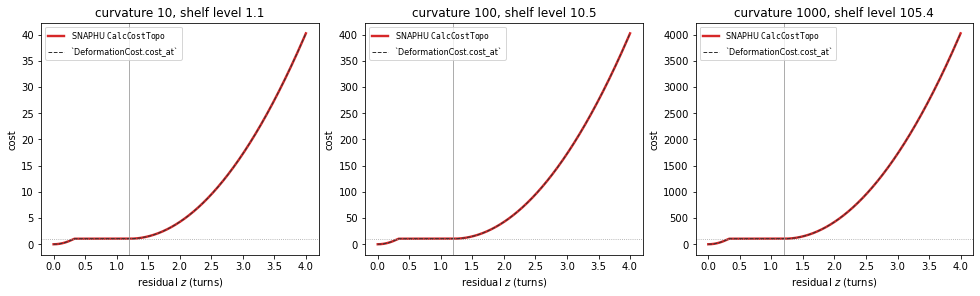

In [12]:
figure, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), constrained_layout=True)

for axis, curvature in zip(axes, (10.0, 100.0, 1000.0)):
    level = curvature * np.log(1.0 / 0.9)
    axis.plot(residual, snaphu_cost(residual, 1.0 / curvature, level),
              color='tab:red', lw=2.4,
              label='SNAPHU $\\mathtt{CalcCostTopo}$')
    model = DeformationCost(np.array([curvature]), np.array([0.0]),
                            shelf=np.array([True]), level=np.array([level]),
                            defomax=1.2, falloff=2.0)
    axis.plot(residual, model.cost_at(arcs, residual), color='0.2',
              lw=1.0, ls='--',
              label='`DeformationCost.cost_at`')
    axis.axvline(1.2, color='0.6', lw=0.8)
    axis.axhline(level, color='0.6', lw=0.8, ls=':')
    axis.set_title('curvature %.0f, shelf level %.1f' % (curvature, level))
    axis.set_xlabel('residual $z$ (turns)')
    axis.set_ylabel('cost')
    axis.legend(fontsize=8, loc='upper left')

plt.show()


The two curves are on top of each other, and both features of the law are
visible: the quadratic branch from the origin, its cap on the shelf, and
the shallower falloff that resumes past the knee at $z = 1.2$ turns. The
dashed vertical line is `defomax`, the dotted horizontal one is the shelf
level. Changing `curvature` moves the height of the whole curve but not the
residual at which the shelf is reached, which is exactly what the
statistical model wants: the *shape* of the penalty is a property of the
noise model, and only its scale depends on the coherence.

### Against the real SNAPHU

The cost law is the same; the solver is not. `stat_cost_unwrap` runs an
iterative refinement over vertex-star moves on top of the same cost model,
and it is small enough to read. The real SNAPHU is a C program with a
proper network-flow solver inside it, and it is worth running side by side
once, both because it is the reference implementation of this family and
because the comparison bounds how much the solver, as opposed to the cost
model, is worth on this scene.

The cell below builds a local SNAPHU if one is present at
`~/Software/snaphu-v2.0.6` and reports its answer next to ours. Two things
about the comparison need stating before the numbers arrive.

* SNAPHU 2.0.6 has **no three-dimensional or stack mode**. Its command line
  offers a single two-dimensional interferogram only; the source declares
  `infileT infiles[1]`, one input. Everything this notebook does with a
  stack is therefore outside what the released program can do, and the
  space--time and EMCF sections have no SNAPHU counterpart to compare
  against.
* SNAPHU's `Total solution cost` is reported in its own internal units,
  which scale with the tile weight, the cost scale and the mode. It is
  therefore *not* directly comparable with the objective this package
  reports. Both numbers are printed; only the field is compared.
* On this scene both SNAPHU modes return **the same field**, and that field
  is the one the statistical-cost implementation returns. That is a
  meaningful agreement -- the two are independently written realisations of
  one cost model -- but it also means the mode distinction is not being
  exercised here: a 32 $\times$ 32 scene with one steep hill has a
  least-cost answer that both laws happen to share.


In [13]:
SNAPHU = Path.home() / 'Software' / 'snaphu-v2.0.6' / 'bin' / 'snaphu'


def run_snaphu(mode, phase, coherence, workdir):
    """Run the local SNAPHU on one image and read its raster back."""
    workdir.mkdir(parents=True, exist_ok=True)
    infile = workdir / 'phase.dat'
    costfile = workdir / 'coherence.dat'
    outfile = workdir / 'unwrapped.dat'
    np.asarray(phase, dtype=np.float32).tofile(str(infile))
    np.asarray(coherence, dtype=np.float32).tofile(str(costfile))
    command = [str(SNAPHU), mode,
               '-C', 'INFILEFORMAT FLOAT_DATA',
               '-C', 'OUTFILEFORMAT FLOAT_DATA',
               '-C', 'CORRFILEFORMAT FLOAT_DATA',
               '-c', str(costfile), '-o', str(outfile),
               str(infile), str(phase.shape[1])]
    completed = subprocess.run(command, cwd=str(workdir), timeout=600,
                               stdout=subprocess.PIPE,
                               stderr=subprocess.STDOUT)
    log = completed.stdout.decode('utf-8', 'replace')
    if not outfile.is_file():
        return None, log
    unwrapped = np.fromfile(str(outfile), dtype=np.float32)
    return unwrapped.reshape(phase.shape), log


if not SNAPHU.is_file():
    print('no local SNAPHU at %s -- skipping this comparison' % (SNAPHU,))
else:
    workdir = Path('/tmp/parvaneh_notebook_snaphu')
    for mode, ours, shelf in (('-s', 'smooth', False), ('-d', 'defo', True)):
        snaphu_field, log = run_snaphu(mode, WRAPPED, GAMMA, workdir)
        field, info = statistical[ours]
        cost = [line for line in log.splitlines()
                if 'total solution cost' in line.lower()]
        print('SNAPHU %s  (costmode %s)' % (mode, ours))
        print('  our rmse           %.4f rad' % rmse(field, CLEAN))
        if snaphu_field is not None:
            print('  SNAPHU rmse        %.4f rad'
                  % rmse(snaphu_field, CLEAN))
            print('  whole turns between the two answers: %d of %d pixels'
                  % (int(np.count_nonzero(
                      np.rint((snaphu_field - field) / (2 * np.pi)))),
                     field.size))
        results['SNAPHU %s' % mode] = rmse(snaphu_field, CLEAN)
        print('  SNAPHU log         %s'
              % (cost[0].strip() if cost else 'n/a for this mode'))
    print()
    print('the log line above is in SNAPHU internal units and is not a')
    print('like-for-like objective; see the note in the text.')


SNAPHU -s  (costmode smooth)
  our rmse           0.7963 rad
  SNAPHU rmse        0.7963 rad
  whole turns between the two answers: 0 of 1024 pixels
  SNAPHU log         Total solution cost: 84801
SNAPHU -d  (costmode defo)
  our rmse           0.7963 rad
  SNAPHU rmse        0.7963 rad
  whole turns between the two answers: 0 of 1024 pixels
  SNAPHU log         Total solution cost: 84801

the log line above is in SNAPHU internal units and is not a
like-for-like objective; see the note in the text.


## 4. Multi-dimensional minimum-cost flow

Costantini's method (1998) is the cleanest of the network formulations and
the one the previous two sections both lean on, so it is worth setting out
before the multi-dimensional question is asked.

**The unknown is a jump per arc.** Give every arc of the grid an integer
$k$ and correct the wrapped step by it:

$$\hat{\Delta}\phi = \operatorname{wrap}(\Delta\psi) + 2\pi k .$$

The wrapped step is used here rather than the raw difference, which is the
opposite choice to PUMA's; it is the same family of unknowns either way.
The difference is that the correction $k$ here counts whole turns *added*,
and $k \equiv 0$ is already a complete-stack answer in the common case of
a well-sampled scene.

**The constraint is integrality of the answer.** A field is single valued
if and only if the corrected steps of every closed loop of the grid add up
to zero. Counting in turns, the loop $C$ imposes

$$\sum_{e \in C} \sigma_{C e} \, k_e = -\,r(C),$$

where $\sigma_{C e} = \pm 1$ records whether the loop walks the arc with or
against its own orientation and $r(C)$ is the residue of the wrapped field
around that loop. The residue is a loop invariant of the measurement -- it
does not depend on the unwrapping, only on the wrapped data -- and it is the
quantity the classical methods are built around (Goldstein, Zebker and
Werner 1988). The elementary squares of the grid generate the whole cycle
space, so constraints on the squares imply the constraints on every loop,
and one row per square is enough.

**The cost.** With a weight $w_e$ per arc, Costantini's objective is the
weighted total variation

$$\min_{k \in \mathbb{Z}^{E}} \sum_{e} w_e |k_e| \quad
\text{subject to} \quad A k = -r ,$$

a linear program in integers. In two dimensions the incidence matrix $A$ of
squares against arcs *is* the incidence matrix of a network -- each arc
lies in at most two squares -- so the integrality of the answer comes for
free from the total unimodularity of network matrices, and the problem is
solved exactly in polynomial time by min-cost flow. That is
`parvaneh.network_flow`, and `flow_nd` uses the same engine through
`curl_flow`.

**Where the third axis breaks it.** An interior arc of a three-dimensional
grid lies on *four* squares, not two, and worse, some arcs lie on two
squares that walk them in the same direction. The squares/arcs incidence
matrix is then no longer a network matrix, the relaxation is no longer
integral, and minimising the integer program is NP-hard in general -- the
argument is Chen and Zebker's (2002), made there for general network models.
The failure is structural: `build_dual_network` refuses a pair of squares
that walk a shared arc the same way, and a volume always contains such a
pair, because the arc that leaves a corner along the first axis is walked
forwards by the square in each of the other two planes. No volume is small
enough to escape this.

`flow_nd` therefore offers three answers:

| `method` | what it does |
| --- | --- |
| `"flow"` | the exact two-dimensional dual network; succeeds only where a network exists |
| `"ilp"` | the same squares solved exactly by LP relaxation plus branch and bound; bounds its search with `max_nodes` and reports `proven` |
| `"slice"` | unwrap every plane independently and leave the across-plane arcs at zero |
| `"auto"` | the network where there is one, branch and bound otherwise, seeded with the slice answer |

and `cost="quadratic"` replaces $w|k|$ with $w k^2$, which spreads the
correction rather than concentrating it -- available only where the
structure is a network, because the exact solver needs a linear objective.


In [14]:
nd = {}
for method in ('flow', 'ilp', 'auto'):
    start = time.perf_counter()
    field, info = flow_nd_unwrap(WRAPPED, method=method, return_info=True)
    elapsed = time.perf_counter() - start
    nd[method] = (field, info)
    print('method %-5s -> backend %-16s rmse %.4f rad, total variation %.4f'
          % (method, info.backend, rmse(field, CLEAN),
             info.total_variation))
    print('   cycles %d, residues %d, augmentations %d, relaxations %d, '
          'proven %s, %.2f s'
          % (info.cycles, info.residues, info.augmentations,
             info.relaxations, info.proven, elapsed))
    print('   congruent to the input: %s' % (congruent(field, WRAPPED),))
    results['N-D network flow, %s' % method] = rmse(field, CLEAN)
    turns = np.rint((field - nd['flow'][0]) / (2 * np.pi))
    print('   differs from the linear-cost flow answer by whole turns on '
          '%d of %d pixels' % (int(np.count_nonzero(turns)), field.size))


method flow  -> backend grid-network     rmse 0.8386 rad, total variation 45.0000
   cycles 961, residues 74, augmentations 37, relaxations 0, proven True, 0.28 s
   congruent to the input: True
   differs from the linear-cost flow answer by whole turns on 0 of 1024 pixels
method ilp   -> backend grid-branch-bound rmse 0.8176 rad, total variation 45.0000
   cycles 961, residues 74, augmentations 0, relaxations 1, proven True, 0.02 s
   congruent to the input: True
   differs from the linear-cost flow answer by whole turns on 5 of 1024 pixels
method auto  -> backend grid-network     rmse 0.8386 rad, total variation 45.0000
   cycles 961, residues 74, augmentations 37, relaxations 0, proven True, 0.28 s
   congruent to the input: True
   differs from the linear-cost flow answer by whole turns on 0 of 1024 pixels


In [15]:
quadratic, quadratic_info = flow_nd_unwrap(WRAPPED, cost='quadratic',
                                           method='flow', return_info=True)
print('cost="quadratic", method="flow"')
print('   rmse %.4f rad, objective %.6f, backend %s'
      % (rmse(quadratic, CLEAN), quadratic_info.objective,
         quadratic_info.backend))
print('   turns differ from the linear-cost answer on %d of %d pixels'
      % (int(np.count_nonzero(np.rint((quadratic - nd['flow'][0])
                                      / (2 * np.pi)))), quadratic.size))
print('   maximum |turn| is %d for the linear cost and %d for the quadratic'
      % (int(np.abs(np.rint((nd['flow'][0] - WRAPPED)
                            / (2 * np.pi))).max()),
         int(np.abs(np.rint((quadratic - WRAPPED) / (2 * np.pi))).max())))
print()
print('the two cost models agree on the field but not on the jumps, which')
print('is the difference between concentrating and spreading a change.')


cost="quadratic", method="flow"
   rmse 0.8317 rad, objective 45.000000, backend grid-network
   turns differ from the linear-cost answer on 1 of 1024 pixels
   maximum |turn| is 3 for the linear cost and 3 for the quadratic

the two cost models agree on the field but not on the jumps, which
is the difference between concentrating and spreading a change.


### Counting the squares of a volume

Before the demonstration it is worth getting the arithmetic right, because
the count is the single number that decides whether an exact volume solve
is feasible at all. For a cubic volume of $n$ samples along each axis, the
squares are counted as follows: a square lies in one of the three
coordinate planes, so pick the plane; along the two axes the square spans,
it can start at any of $n - 1$ positions; and it can sit at any of the $n$
layers across the remaining axis. That gives

$$N_{\text{squares}} = 3\,n\,(n-1)^2 , \qquad
N_{\text{arcs}} = 3\,n^2 (n-1) .$$

A two-dimensional $n \times n$ grid is the same formula without the
factor for the remaining axis, $N = (n-1)^2$. The cell below measures both
counts rather than trusting them, which is how an earlier mistaken figure
of $3(n-1)^3$ in the module's own documentation -- low by a factor of
$n/(n-1)$, and wrong in the accompanying cost table too -- was caught and
corrected. The counts matter: at $64^3$ the correction adds twelve thousand
rows to every linear relaxation.


In [16]:
print('%9s %9s %9s %9s %9s' % ('shape', 'nodes', 'arcs', 'squares',
                               '3n(n-1)^2'))
for shape in ((32, 32), (8, 8, 8), (16, 16, 16), (32, 32, 32),
              (64, 64, 64)):
    index = grid_edge_index(shape)
    squares = len(grid_cycles(shape, index))
    arcs = sum(part.size for part in index)
    nodes = int(np.prod(shape))
    predicted = sum(
        (shape[a] - 1) * (shape[b] - 1) * int(np.prod(
            [shape[c] for c in range(len(shape)) if c not in (a, b)]))
        for a in range(len(shape)) for b in range(a + 1, len(shape)))
    print('%9s %9d %9d %9d %9d'
          % ('x'.join(str(s) for s in shape), nodes, arcs, squares,
             predicted))
print()
print('the measured count matches 3 n (n - 1)^2 exactly, and a 64^3')
print('volume needs 762048 relaxation rows, twelve thousand more than')
print('the erroneous 3 (n - 1)^3 would suggest.')


    shape     nodes      arcs   squares 3n(n-1)^2
    32x32      1024      1984       961       961
    8x8x8       512      1344      1176      1176
 16x16x16      4096     11520     10800     10800
 32x32x32     32768     95232     92256     92256
 64x64x64    262144    774144    762048    762048

the measured count matches 3 n (n - 1)^2 exactly, and a 64^3
volume needs 762048 relaxation rows, twelve thousand more than
the erroneous 3 (n - 1)^3 would suggest.


In [17]:
def grid_steps(phase):
    """Wrapped step of every arc, in the order grid_edges lists them."""
    return np.concatenate([wrap_phase(np.diff(phase, axis=axis)).ravel()
                           for axis in range(phase.ndim)])


def network_report(shape):
    """Describe the cycle structure of a grid and its dual network."""
    nodes, tail, head = grid_edges(shape)
    squares = grid_cycles(shape, grid_edge_index(shape))
    residues = residues_of_cycles(np.zeros(tail.size), squares)
    network = build_dual_network(squares, residues, tail.size)
    return nodes, tail, squares, network


volume = wrap_phase(np.stack([
    add_phase_noise(CLEAN + 0.3 * k, GAMMA, looks=4,
                    rng=np.random.default_rng(20 + k))
    for k in range(3)]))

for shape in (volume.shape, (3, 3, 3), volume.shape[1:]):
    nodes, tail, squares, network = network_report(shape)
    print('shape %-10s nodes %5d  arcs %5d  squares %5d  '
          'dual network exists: %s'
          % (str(shape), nodes.size, tail.size, len(squares),
             network is not None))

labels = {volume.shape: 'a volume', (3, 3, 3): 'the smallest volume',
          volume.shape[1:]: 'one plane'}
volume_squares = residues_of_cycles(grid_steps(volume),
                                    grid_cycles(volume.shape,
                                                grid_edge_index(
                                                    volume.shape)))
print()
print('the volume carries %d nonzero residues over %d squares'
      % (int(np.count_nonzero(volume_squares)),
         volume_squares.size))

for method in ('flow', 'auto', 'ilp', 'slice'):
    try:
        field, info = flow_nd_unwrap(volume, method=method,
                                     return_info=True)
        print('  method=%-5s -> backend %-18s proven %-5s slices %d'
              % (method, info.backend, info.proven, info.slices))
    except ValueError as error:
        print('  method=%-5s -> ValueError: %s' % (method, error))

print()
for cost, method in (('quadratic', 'auto'), ('quadratic', 'ilp')):
    try:
        flow_nd_unwrap(volume, cost=cost, method=method)
        print('  cost=%-9s method=%-4s -> solved' % (cost, method))
    except ValueError as error:
        print('  cost=%-9s method=%-4s -> ValueError: %s'
              % (cost, method, error))


shape (3, 32, 32) nodes  3072  arcs  8000  squares  6851  dual network exists: False
shape (3, 3, 3)  nodes    27  arcs    54  squares    36  dual network exists: False
shape (32, 32)   nodes  1024  arcs  1984  squares   961  dual network exists: True

the volume carries 485 nonzero residues over 6851 squares
  method=flow  -> ValueError: these cycles do not form a flow network
  method=auto  -> backend grid-branch-bound  proven True  slices 0
  method=ilp   -> backend grid-branch-bound  proven True  slices 0
  method=slice -> backend grid-slice         proven True  slices 3

  cost=quadratic method=auto -> ValueError: a general cost network is not a flow network, so only the linear cost can be solved by branch and bound
  cost=quadratic method=ilp  -> ValueError: a general cost network is not a flow network, so only the linear cost can be solved by branch and bound


The volume raises, the plane does not, and the two error messages
distinguish the two reasons a call can fail: a *linear* cost on a
non-network cycle set fails because the cycles themselves are not a flow
network, while a *quadratic* cost fails earlier still because branch and
bound needs a linear objective. Both checks are pinned in the test suite.

### Does the third axis help?

The case with an obvious interferometric meaning is a *stack of the same
scene*: six epochs of the experiment above, unwrapped slice by slice, or
unwrapped as one volume. The grid axes of the volume are then the two
spatial axes and the time axis, and the question is whether the solver can
use the fact that a pixel's phase history is smooth. The scene is the same
one, so the numbers are directly comparable with sections 2 and 3.


In [18]:
results['wrapped input'] = rmse(STACK, STACK_TRUTH)

two_d = np.stack([flow_nd_unwrap(STACK[k]) for k in range(EPOCHS)])
results['six independent 2-D solves'] = rmse(two_d, STACK_TRUTH)

per_axis = {}
for axis in range(3):
    volume_stack = np.moveaxis(STACK, 0, axis)
    start = time.perf_counter()
    estimate = flow_nd_unwrap(volume_stack, slice_axis=axis)
    elapsed = time.perf_counter() - start
    value = rmse(np.moveaxis(estimate, axis, 0), STACK_TRUTH)
    per_axis[axis] = value
    print('time axis placed at axis %d: rmse %.4f rad in %.2f s'
          % (axis, value, elapsed))

results['one 3-D flow solve, best axis'] = min(per_axis.values())

for epoch in range(EPOCHS):
    print('   epoch %d: independent 2-D rmse %.4f rad'
          % (epoch, rmse(two_d[epoch], STACK_TRUTH[epoch])))

print()
print('wrapped input, i.e. no unwrapping at all : %.4f rad'
      % results['wrapped input'])
print('six independent two-dimensional solves  : %.4f rad'
      % results['six independent 2-D solves'])
print('one three-dimensional solve, best axis  : %.4f rad'
      % min(per_axis.values()))
print('improvement of 3-D over per-slice 2-D   : %.1f %%'
      % (100.0 * (1.0 - min(per_axis.values())
                 / results['six independent 2-D solves'])))


time axis placed at axis 0: rmse 0.8103 rad in 1.95 s
time axis placed at axis 1: rmse 0.8064 rad in 1.98 s
time axis placed at axis 2: rmse 0.8073 rad in 4.90 s
   epoch 0: independent 2-D rmse 1.0601 rad
   epoch 1: independent 2-D rmse 0.8232 rad
   epoch 2: independent 2-D rmse 0.9367 rad
   epoch 3: independent 2-D rmse 0.8301 rad
   epoch 4: independent 2-D rmse 1.3374 rad
   epoch 5: independent 2-D rmse 1.2952 rad

wrapped input, i.e. no unwrapping at all : 3.6969 rad
six independent two-dimensional solves  : 1.0672 rad
one three-dimensional solve, best axis  : 0.8064 rad
improvement of 3-D over per-slice 2-D   : 24.4 %


The third axis is a real gain here: joining the six planes into one solve
removes about a quarter of the error that the six independent solves leave
behind, and the three choices of which axis is treated as the third agree
with each other to within 0.004 rad. That agreement is itself a check --
the same volume solved with a different axis ordering should be the same
problem up to relabelling, and it is.

Look at the per-epoch line as well. The independent solves are not equally
good: the epoch that happened to draw the worst noise realisation is the
one that decides the stack's number, and a joint solve has no reason to
keep that inequality, because a wrong turn in one epoch shows up as an
inconsistency along the time axis. That is the mechanism by which the third
dimension pays.


### The same sorter, in three dimensions

The reliability sort is not restricted to two dimensions. Abdul-Rahman,
Gdeisat, Burton and Lalor (2005) extended the sort of Herraez et al. (2002)
to an array of phase with a third axis, and `unwrap_phase` dispatches on the
number of axes it is handed. It is therefore the natural control group for
the question above. If a third axis helps because the loops that run along
it are *new information*, it should help the sorter as well; if it helps
only when a whole turn can be priced against a neighbour, it will not.


In [19]:
if HAVE_SKIMAGE:
    volume_truth = CLEAN[None, :, :] + 0.3 * np.arange(3.0)[:, None, None]

    start = time.perf_counter()
    volume_3d = skimage_unwrap(volume)
    elapsed_volume = time.perf_counter() - start
    volume_2d = np.stack([skimage_unwrap(volume[k]) for k in range(3)])
    volume_reli = np.stack([reliability_unwrap(volume[k])
                            for k in range(3)])
    results['reliability sort, scikit-image, 3-D'] = rmse(volume_3d,
                                                          volume_truth)

    print('the volume of the section above, %d x %d x %d'
          % volume.shape)
    print('  sorter, plane by plane             : %.4f rad'
          % rmse(volume_2d, volume_truth))
    print('  sorter, one 3-D call               : %.4f rad in %.2f s'
          % (results['reliability sort, scikit-image, 3-D'],
             elapsed_volume))
    print('  this package, the same sorter      : %.4f rad'
          % rmse(volume_reli, volume_truth))
    print('  this package, 3-D flow             : %.4f rad'
          % rmse(flow_nd_unwrap(volume), volume_truth))
    print()
    print('the six-epoch stack, %d planes' % EPOCHS)
    start = time.perf_counter()
    stack_3d = skimage_unwrap(STACK)
    elapsed_stack = time.perf_counter() - start
    stack_2d = np.stack([skimage_unwrap(STACK[k])
                         for k in range(EPOCHS)])
    print('  sorter, epoch by epoch             : %.4f rad'
          % rmse(stack_2d, STACK_TRUTH))
    print('  sorter, one 3-D call               : %.4f rad in %.2f s'
          % (rmse(stack_3d, STACK_TRUTH), elapsed_stack))
    print('  this package, six 2-D flows        : %.4f rad'
          % results['six independent 2-D solves'])
    print('  this package, 3-D flow             : %.4f rad'
          % results['one 3-D flow solve, best axis'])


the volume of the section above, 3 x 32 x 32
  sorter, plane by plane             : 1.0662 rad
  sorter, one 3-D call               : 0.9923 rad in 0.00 s
  this package, the same sorter      : 1.3014 rad
  this package, 3-D flow             : 0.8022 rad

the six-epoch stack, 6 planes
  sorter, epoch by epoch             : 2.1578 rad
  sorter, one 3-D call               : 1.2679 rad in 0.00 s
  this package, six 2-D flows        : 1.0672 rad
  this package, 3-D flow             : 0.8064 rad


The third axis does help a sorter, and that is the honest half of the story.
On the volume above, one three-dimensional call beats the three calls that
solve the planes separately, and on the six-epoch stack the gap is much
wider: the independent sorts leave around two rad, with two of the six
epochs failing badly, where the joint call leaves well under one and a half.
Part of what a three-dimensional problem buys is therefore available to any
method at all, and the mechanism is simply a better *order* in which to
commit to an arc, because a wrong turn can now contradict a neighbour along
the third axis as well.

It is not the whole story, and the sizes say so. On the same volume, the
three-dimensional flow of the section above is better than the sorter's
three-dimensional call by roughly a fifth, and on the stack the sorter's
joint call is still clearly behind the flow and behind the six independent
flow solves it should have beaten. The third axis is worth a few percent to
a path follower and around a quarter to a solver, and the difference between
the two is that a solver can *charge* for a contradiction while a sorter can
only avoid it.

Two details of the comparison, so that it is not read as more than it is.

The first is the gauge. Every error above removes the mean of each plane
separately, for the baseline and for this package alike, so neither is
rewarded or punished for the arbitrary per-plane offset of an unwrapped
field; removing a single global constant instead moves both numbers a little
at the third decimal and does not change the ranking. The second is that a
sorter has no objective. There is no scalar that it minimises, so there is
nothing to check afterwards, no way to trade a turn on one arc against a
turn on another, and no certificate that the answer it returned is the best
one available to it. What is left is the gap that the rest of this notebook
is about.


## 5. Space-time unwrapping, after StaMPS

The method of section 4 put time on a *third grid axis*, so that the loops
of the grid wind through time and the solver has to satisfy them. StaMPS
uses time differently (Hooper, Segall and Zebker 2007; Hooper 2008;
Chen and Zebker 2002): the grid stays two dimensional, and the
stack of acquisitions supplies a **prior** for every arc instead of a new
family of constraints.

### The prior

Write $g_{t,a}$ for the wrapped measurement of observation $t$ at arc $a$,
in radians, and $d_t$ for the days of the observations. For observation
$i$ the window around it is Gaussian in time,

$$
w_{t} \propto \exp\left(-\frac{(d_i - d_t)^2}{2 \tau^2}\right),
\qquad \sum_t w_t = 1,
$$

with $\tau$ the ``time_win`` parameter (180 days by default). The
measurements are averaged *as complex numbers*, which is an average of the
phase that the wrapping cannot spoil:

$$
\phi_i = \arg \sum_t w_t \, e^{\mathrm{i} g_{t,a}} .
$$

The measurements are then brought next to that reference,
$r_{t} = \mathrm{wrap}(g_{t,a} - \phi_i)$, and a straight line
$a + b \, (d_t - d_i)$ is fitted to them by weighted least squares. The
prediction keeps the **intercept only**:

$$
\hat{g}_{i,a} = \phi_i + a .
$$

Dropping the slope is deliberate and it is what Hooper, Segall and Zebker
(2007) do: the slope is a
phase rate, that is a deformation rate, and estimating it from a handful of
acquisitions would mix the quantity being measured into the thing
predicting it.

### From a prediction to a price

A prediction is a real number, a measurement is known only modulo one turn,
so let $L_{i,a}$ be the integer that makes the two agree:

$$
\hat{g}_{i,a} = g_{i,a} + 2\pi L_{i,a} + \nu_{i,a},
\qquad \nu_{i,a} = \mathrm{wrap}(g_{i,a} - \hat{g}_{i,a}).
$$

If the flow adds $k_{i,a}$ whole turns to arc $a$ of observation $i$, then
the error of that arc *measured in turns against the prediction* is

$$
\frac{g_{i,a} + 2\pi k_{i,a} - \hat{g}_{i,a}}{2\pi}
  = k_{i,a} - \frac{\hat{g}_{i,a} - g_{i,a}}{2\pi}
  = k_{i,a} - c_{i,a},
$$

which defines the fractional **centre** $c_{i,a}$. The cost of the arc is
that squared error in turns, scaled by the confidence of the arc and by the
reciprocal of the variance of the prediction error, which is exactly the
:class:`parvaneh.graph_flow.QuadraticCost` of the engine:

$$
\text{cost}(k) = \underbrace{\frac{w_a}{\sigma_a^2}}_{\text{curvature}}
                 \, (k - c_{i,a})^2 .
$$

$\sigma_a^2$ is the **sample variance of $\nu$ over the stack**, so it is
one number per arc for the whole stack, while the centre is one number per
arc *and* observation. The cost is convex, so the exact minimum over all
integer flows is found by `curl_flow` -- this method, unlike the heuristic
ones above, has an optimality certificate, and `info.proven` reports it.

### The noise gate

An arc whose prediction error has a large spread is not trusted. StaMPS
calls it when the sample standard deviation of $\nu$ over the stack
exceeds ``noise_gate`` (1.3 rad), and then the arc loses its statistics.
The bookkeeping of Chen and Zebker (2002) is reproduced by the default
``gate="floor"``: the
cost file cannot store a huge variance and a zero entry makes SNAPHU fail,
so such an arc keeps the smallest entry the format allows and is asked for
**no correction at all** at the price of the floor variance. The other
reading of the same flag is ``gate="free"``, which drops the cost of a
gated arc instead and leaves it to the residue constraints.

### Two ways to build the prior

* **Interferogram mode** (default): ``day`` has one entry per observation,
  and the prior is the smoothed within-window average described above
  (Hooper, Segall and Zebker 2007).
* **Series mode**: the caller passes a ``design`` matrix $D$ with one row
  per observation and one column per epoch, so a pair measured between
  epochs $u < v$ has $-1$ in column $u$ and $+1$ in column $v$. One series
  per arc is fitted to the whole stack at once, smoothed in time, and
  projected back onto the observations (Hooper 2008). This is the
  small-baseline
  variant, and it is the one that sews a stack of pairs into a time series.

### What this notebook does, and what it does not

The window matters for reading the numbers below. ``time_win`` is 180
days while the six acquisitions here are one day apart, so the Gaussian
weights differ from one another by less than 0.05 % and the reference
$\phi_i$ is essentially the complex mean of the six observations. The prior
therefore asks for very little: what it supplies is a price on disagreeing
with the rest of the stack rather than new information about any single
epoch. On a real StaMPS stack, which spans months or years, the same
window is a genuinely local average and the same prior is a much stronger
statement; the arithmetic of this section is unchanged either way.

Real StaMPS consumes a network of *interferograms*, whose priors share
epochs and are therefore correlated. Here the six planes of `STACK` are
handed over as six observations with ``day = 0 ... 5``, which is the model
the prior arithmetic actually needs, and it is what makes the numbers of
this section comparable with the six independent two-dimensional solves of
section 4. The look-angle ramp, the shakiness branch ``scf_flag``, the
predefined arcs and the narrowing of the gate in the small-baseline mode
are all left out; they are listed in the module docstring.

The time window, the gate, the window-weighted average and the
reproduction of the SNAPHU cost file are all described in Hooper, Segall
and Zebker, *JGR* 112 (2007) B07407; the small-baseline series mode is
Hooper, *GRL* 35 (2008) L16302; and the cost file itself, with its floor
variance and its deformation model, is Chen and Zebker, *IEEE TGRS* 40(8)
(2002) 1709-1719. The wider treatment of the same chain is Hooper, Bekaert,
Spaans and Arikan, *Tectonophysics* 514-517 (2012) 1-13.


In [20]:
# A per-arc shakiness, on the same scale as the ``spread`` of StaMPS: it is
# divided by six before it is added to the variance of the prior.
SPREAD = np.full(NARCS, 0.05)

# The settings of the method, at their defaults. ``space_time_priors``
# and ``space_time_unwrap`` build one of these when none is handed in.
ST_PARAMS = SpaceTimeParams()

# The small-baseline variant: five consecutive pairs of the six epochs,
# with a design matrix that says which epochs each pair measures.
PAIRS = np.array([[k, k + 1] for k in range(EPOCHS - 1)])
CHAIN = wrap_phase(STACK[PAIRS[:, 1]] - STACK[PAIRS[:, 0]])
CHAIN_TRUTH = STACK_TRUTH[PAIRS[:, 1]] - STACK_TRUTH[PAIRS[:, 0]]
DESIGN = np.zeros((PAIRS.shape[0], EPOCHS))
DESIGN[np.arange(PAIRS.shape[0]), PAIRS[:, 0]] = -1.0
DESIGN[np.arange(PAIRS.shape[0]), PAIRS[:, 1]] = +1.0

spacetime = {}
runs = (('default', STACK, DAY, {}, STACK_TRUTH),
        ('spread 0.05', STACK, DAY, {'spread': 0.05}, STACK_TRUTH),
        ('spread per arc', STACK, DAY, {'spread': SPREAD}, STACK_TRUTH),
        ('gate free', STACK, DAY, {'gate': 'free'}, STACK_TRUTH),
        ('series mode', CHAIN, DAY, {'design': DESIGN}, CHAIN_TRUTH))

for name, stack, days, options, truth in runs:
    start = time.perf_counter()
    field, info = space_time_unwrap(stack, days, return_info=True,
                                    **options)
    elapsed = time.perf_counter() - start
    value = rmse(field, truth)
    spacetime[name] = (field, info, truth)
    results['space-time, %s' % name] = value
    print('%-15s mode %-12s observations %d, rmse %.4f rad in %.2f s'
          % (name, info.mode, info.observations, value, elapsed))
    print('  gated arcs %d of %d, window %.0f days, gate %.1f rad, '
          'variance floor %.3g'
          % (info.gated_edges, info.edges, info.time_win,
             info.noise_gate, info.min_variance))
    print('  objective %.4f in total, mean %.4f per observation, '
          'augmentations %d, proven %s'
          % (info.objective, float(np.mean(info.objective_per_observation)),
             info.augmentations, info.proven))


default         mode interferogram observations 6, rmse 1.2090 rad in 2.06 s
  gated arcs 285 of 1984, window 180 days, gate 1.3 rad, variance floor 0.0025
  objective 37042.3488 in total, mean 6173.7248 per observation, augmentations 231, proven True
spread 0.05     mode interferogram observations 6, rmse 1.2275 rad in 2.12 s
  gated arcs 285 of 1984, window 180 days, gate 1.3 rad, variance floor 0.0025
  objective 25802.4163 in total, mean 4300.4027 per observation, augmentations 231, proven True
spread per arc  mode interferogram observations 6, rmse 1.2275 rad in 3.44 s
  gated arcs 285 of 1984, window 180 days, gate 1.3 rad, variance floor 0.0025
  objective 25802.4163 in total, mean 4300.4027 per observation, augmentations 231, proven True
gate free       mode interferogram observations 6, rmse 1.3812 rad in 3.25 s
  gated arcs 285 of 1984, window 180 days, gate 1.3 rad, variance floor 0.0025
  objective 13254.1587 in total, mean 2209.0265 per observation, augmentations 266, prov

In [21]:
priors = space_time_priors(STACK, DAY, params=ST_PARAMS)
spready = space_time_priors(STACK, DAY, params=ST_PARAMS, spread=SPREAD)
gate_spread = np.std(priors.noise, axis=0, ddof=1)
centre_turns = np.abs(priors.centre)
chosen = spacetime['default'][1]
bill = float(np.mean(chosen.objective_per_observation))

print('the default run: %d arcs, %d observations, %d arc-observation slots'
      % (priors.steps.shape[1], priors.steps.shape[0],
         priors.centre.size))
print('  |centre|, the turns the prior asks for: mean %.4f, median %.4f, '
      'p90 %.4f, max %.4f turns'
      % (centre_turns.mean(), np.median(centre_turns),
         np.percentile(centre_turns, 90), centre_turns.max()))
print('  slots asking for more than half a turn: %.2f %%, for one turn or '
      'more: %.2f %%'
      % (100.0 * np.mean(centre_turns > 0.5),
         100.0 * np.mean(centre_turns >= 1.0)))
print('  prediction error: rms %.4f rad, and per arc a sample standard '
      'deviation of median %.4f, p90 %.4f, max %.4f rad'
      % (np.sqrt(np.mean(priors.noise ** 2)), np.median(gate_spread),
         np.percentile(gate_spread, 90), gate_spread.max()))
print('  the %.1f rad gate therefore silences %d of %d arcs (%.2f %%)'
      % (ST_PARAMS.noise_gate, int(np.count_nonzero(priors.gated)),
         priors.gated.size,
         100.0 * np.count_nonzero(priors.gated) / priors.gated.size))
print('  curvature, the price of one whole turn squared: median %.2f, '
      'range %.2f .. %.2f'
      % (np.median(priors.curvature), priors.curvature.min(),
         priors.curvature.max()))
print('  a gated arc is pinned instead, at %.2f, which is 1 / %.4g, the '
      'variance floor'
      % (1.0 / ST_PARAMS.min_variance, ST_PARAMS.min_variance))
print('  raising the spread to %.2f per arc leaves the curvature at a '
      'median of %.2f' % (SPREAD[0], np.median(spready.curvature)))
print()
print('for scale, one whole turn off on a median arc costs %.0f per '
      'observation, while the default run pays %.0f per observation, so a '
      'misplaced turn is %.1f %% of one bill'
      % (np.median(priors.curvature), bill,
         100.0 * np.median(priors.curvature) / bill))


the default run: 1984 arcs, 6 observations, 11904 arc-observation slots
  |centre|, the turns the prior asks for: mean 0.0815, median 0.0472, p90 0.1781, max 1.1259 turns
  slots asking for more than half a turn: 2.02 %, for one turn or more: 0.11 %
  prediction error: rms 0.8061 rad, and per arc a sample standard deviation of median 0.6981, p90 1.3799, max 2.0684 rad
  the 1.3 rad gate therefore silences 285 of 1984 arcs (14.36 %)
  curvature, the price of one whole turn squared: median 144.61, range 23.37 .. 400.00
  a gated arc is pinned instead, at 400.00, which is 1 / 0.0025, the variance floor
  raising the spread to 0.05 per arc leaves the curvature at a median of 65.58

for scale, one whole turn off on a median arc costs 145 per observation, while the default run pays 6174 per observation, so a misplaced turn is 2.3 % of one bill


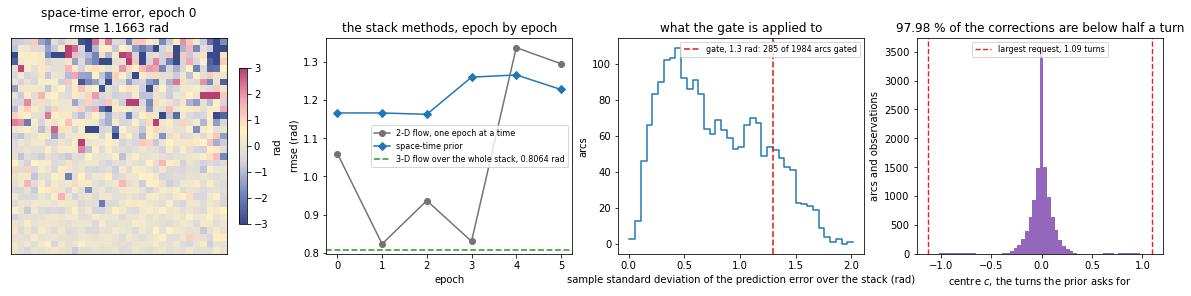

In [22]:
figure, axes = plt.subplots(1, 4, figsize=(16.5, 4.0), constrained_layout=True)

field, info, truth = spacetime['default']
artist = axes[0].imshow(field[0] - truth[0], origin='lower',
                        cmap=SAKURA_DIVERGING, vmin=-3.0, vmax=3.0)
axes[0].set_title('space-time error, epoch 0\nrmse %.4f rad'
                  % rmse(field[0], truth[0]))
figure.colorbar(artist, ax=axes[0], shrink=.72, label='rad')

per_epoch_2d = [rmse(two_d[k], STACK_TRUTH[k]) for k in range(EPOCHS)]
per_epoch_st = [rmse(field[k], truth[k]) for k in range(EPOCHS)]
axes[1].plot(range(EPOCHS), per_epoch_2d, 'o-', color='0.45',
             label='2-D flow, one epoch at a time')
axes[1].plot(range(EPOCHS), per_epoch_st, 'D-', color='tab:blue',
             label='space-time prior')
axes[1].axhline(results['one 3-D flow solve, best axis'],
                color='tab:green', ls='--', lw=1.6,
                label='3-D flow over the whole stack, %.4f rad'
                      % results['one 3-D flow solve, best axis'])
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('rmse (rad)')
axes[1].set_title('the stack methods, epoch by epoch')
axes[1].legend(fontsize=8)

counts, edges = np.histogram(gate_spread, bins=40)
axes[2].step(edges[:-1], counts, where='post', color='tab:blue')
axes[2].axvline(ST_PARAMS.noise_gate, color='tab:red', lw=1.6, ls='--',
                label='gate, %.1f rad: %d of %d arcs gated'
                      % (ST_PARAMS.noise_gate,
                         int(np.count_nonzero(priors.gated)),
                         priors.gated.size))
axes[2].set_xlabel('sample standard deviation of the prediction error '
                   'over the stack (rad)')
axes[2].set_ylabel('arcs')
axes[2].set_title('what the gate is applied to')
axes[2].legend(fontsize=8)

centre = np.asarray(priors.centre).ravel()
axes[3].hist(centre, bins=60, color='tab:purple')
axes[3].axvline(centre.max(), color='tab:red', lw=1.4, ls='--',
                label='largest request, %.2f turns' % (centre.max(),))
axes[3].axvline(centre.min(), color='tab:red', lw=1.4, ls='--')
axes[3].set_xlabel('centre $c$, the turns the prior asks for')
axes[3].set_ylabel('arcs and observations')
axes[3].set_title('%.2f %% of the corrections are below half a turn'
                  % (100.0 * np.mean(np.abs(centre) < 0.5),))
axes[3].legend(fontsize=8)
for axis in (axes[0],):
    axis.set_xticks([])
    axis.set_yticks([])
plt.show()


Three things are worth reading off the figure.

The per-epoch panel answers the question of the section, and the answer is
negative. The prior is worse than unwrapping each epoch on its own on four
of the six epochs -- by 0.11, 0.34, 0.23 and 0.43 rad -- and better on the
last two by less than 0.08 rad. It also *flattens* the profile: the spread
between the best and the worst epoch falls from 0.51 rad for the six
independent solves to 0.10 rad here. That is what a shared prior does. It
pulls every arc towards what the rest of the stack says, so a hard epoch
improves and an easy one is dragged down with it; on this scene the drag
wins. The stack total is 1.2090 rad against 1.0672 rad, about 13 % worse,
and both are behind the 0.8064 rad of the three-dimensional flow of
section 4.

The spread histogram shows why the gate exists, and that it does work. The
median arc has a prediction error with a sample standard deviation of
0.70 rad over the stack and the ninetieth percentile is 1.38 rad, so the
1.3 rad gate cuts away 285 of the 1984 arcs, 14.4 % of the network. Those
arcs are then not solved from the stack at all: ``gate="floor"`` pins them
to zero turns at the price of the variance floor. Turning the gate off
instead, with ``gate="free"``, costs 0.17 rad, which is the clearest sign
that the prior is the only information the method has.

The centre histogram is the other half of the same story. The prior asks
for very little: the mean absolute request is 0.08 turns, 2.0 % of the
arc-observation slots want more than half a turn, and the largest request
anywhere in the stack is 1.13 turns. The six acquisitions are one day
apart, so the 180 day window is effectively a plain mean of the stack and
the reference it produces is close to the measurement it is correcting.
What the method contributes is a price rather than information, and a price
is all a prior is: one whole turn on a median arc adds about 145 to an
objective of about 6174 per observation, some 2 %, which discourages a
wrong turn without overruling anything. The loops are where the
measurements enter, and they stay hard constraints.

Two variations on the same theme are worth quoting. The ``spread``
parameter, the per-arc shakiness of StaMPS, costs 0.02 rad when raised to
0.05 per arc (1.2275 against 1.2090) and halves the curvature, from a
median of 144.6 to 65.6: a shakier arc is trusted less, exactly as
intended. The small-baseline series mode of the same module works too, on
its own stack of five consecutive pairs with one series fitted per arc; it
reaches 1.6248 rad against that stack's own truth and gates 834 of the
1984 arcs, which is what a shorter stack of pairs buys.

That is the honest summary of this section: the mechanism is implemented in
full and its optimum is exact, and on six acquisitions one day apart it
does not pay. Section 8 comes back to the point.


## 6. Extended minimum cost flow, after Pepe and Lanari

EMCF takes the opposite decision from StaMPS about where the stack enters.
It does not build a statistical prior at all: it treats the stack
combinatorially and *removes the turns that make the stack inconsistent*,
then unwraps each interferogram in space as if it were alone (Pepe and
Lanari 2006; Costantini 1998).

### The two families of loops

Unwrapping one interferogram is the integer problem of section 4: choose a
whole number of turns $k_a$ for every arc $a$ of the grid so that the
signed sum of the corrected differences around every loop of the grid
cancels that loop's residue,

$$
\sum_{a \in \partial S} \left( \pm (g_a + 2\pi k_a) \right) = 0
\quad \text{for every elementary square } S .
$$

A stack adds a second family. The acquisitions are the vertices of a small
graph whose edges are the interferograms: edge $j$ joins the earlier
acquisition of its pair to the later one, so its measurement is a
difference of one acquisition from another. The measurements of a *single
arc of the image* are then also differences along a graph, and every closed
chain of acquisitions has to close for that arc:

$$
r_c = \mathrm{rint}\!\left( \frac{1}{2\pi} \sum_j \sigma_{c,j}
      u_j \right),
\qquad
\sum_j \sigma_{c,j} k_j = -r_c ,
$$

where $u_j$ is the measurement of interferogram $j$ at that arc and
$\sigma_{c,j} = \pm 1$ is the sense in which loop $c$ walks edge $j$.
This is a supply constraint of a network flow: loop $c$ has to send the
residue $r_c$ away, and the turns $k$ are the flow. The default network
here is the hop-three network of Pepe and Lanari (2006), which joins
acquisitions one, two or
three steps apart: with $E$ epochs it has $3E - 6$ edges and $2E - 5$
triangular loops -- for the six epochs of this experiment, $12$ links and
$7$ loops.

### Time first, space second

The temporal stage is cheap because the arcs of the image do not interact
in it: the price of a turn is one for every interferogram, so each arc has
its own small flow problem with the same graph and the same prices, and
arcs whose temporal residues all vanish are left alone, since the cheapest
way to close a loop that already closes is to add nothing. Then the
corrected measurements $g_j + 2\pi k_j$ close every temporal loop, and the
spatial stage unwraps each corrected interferogram with the
confidence-weighted cost of the other wrapped methods. The turns that reach
the integration are $k_j + f_j$, whose sum closes every loop of the image
*by construction* -- which is why the walk that integrates them does not
depend on the order it takes.

Both stages are solved here by the same `curl_flow`, and both are exact:
unlike the graph cuts of section 2, this is a minimum cost flow, not a
heuristic.

The temporal network and the two-stage split are Pepe and Lanari, *IEEE
TGRS* 44(9) (2006) 2374-2383; the underlying minimum cost flow formulation
is Costantini, *IEEE TGRS* 36(3) (1998) 813-821; the network details follow
the ``spurt`` implementation of Calef, Agram, Olsen, Staniewicz, Gunter and
Fattahi (2024), which is also where the name "extended minimum cost flow"
crossed into an open Python codebase; and the full processing chain is Pepe,
Euillades, Manunta and Lanari, *IEEE TGRS* 49(10) (2011) 4062-4079.


In [23]:
emcf = {}
runs = (('default links', {}),
        ('explicit links', {'links': LINKS}),
        ('branch and bound', {'links': LINKS, 'method': 'ilp'}))

for name, options in runs:
    start = time.perf_counter()
    stack, info = emcf_unwrap(STACK, return_info=True, **options)
    elapsed = time.perf_counter() - start
    value = rmse(stack, EMCF_TRUTH)
    emcf[name] = (stack, info)
    results['EMCF, %s' % name] = value
    print('%-17s network %-10s interferograms %d, rmse %.4f rad in %.2f s'
          % (name, info.network, info.interferograms, value, elapsed))
    print('  temporal stage: %d pixels solved, %d loops closed, '
          '%d residues, %d turns added'
          % (info.temporal_solves, info.cycles, info.temporal_residues,
             info.temporal_turns))
    print('  spatial stage : cycles %d, residues %d, components %d, '
          'proven %s' % (info.cycles, info.residues, info.components,
                         info.proven))
    print('  objective %.4f in total, %.4f per interferogram, backends %s'
          % (info.objective,
             float(np.mean(info.objective_per_interferogram)),
             info.backend))
    print('  congruent to its own input: %s'
          % (congruent(stack[0], EMCF_INPUT[0]),))

print()
print('input floor, the hop-three links themselves : %.4f rad'
      % rmse(EMCF_INPUT, EMCF_TRUTH))
print('EMCF                                      : %.4f rad'
      % rmse(emcf['explicit links'][0], EMCF_TRUTH))


default links     network hop3       interferograms 12, rmse 1.3075 rad in 6.71 s
  temporal stage: 523 pixels solved, 7 loops closed, 1130 residues, 777 turns added
  spatial stage : cycles 7, residues 1293, components 1, proven True
  objective 870.0000 in total, 72.5000 per interferogram, backends emcf-flow
  congruent to its own input: True
explicit links    network hop3       interferograms 12, rmse 1.3075 rad in 5.57 s
  temporal stage: 523 pixels solved, 7 loops closed, 1130 residues, 777 turns added
  spatial stage : cycles 7, residues 1293, components 1, proven True
  objective 870.0000 in total, 72.5000 per interferogram, backends emcf-flow
  congruent to its own input: True
branch and bound  network hop3       interferograms 12, rmse 1.3154 rad in 1.01 s
  temporal stage: 523 pixels solved, 7 loops closed, 1130 residues, 777 turns added
  spatial stage : cycles 7, residues 1251, components 1, proven True
  objective 877.0000 in total, 73.0833 per interferogram, backends emcf

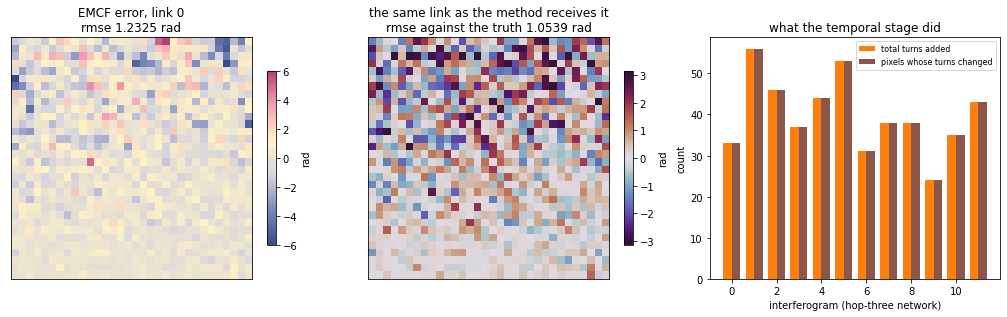

In [24]:
figure, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), constrained_layout=True)

stack, info = emcf['explicit links']
artist = axes[0].imshow(stack[0] - EMCF_TRUTH[0], origin='lower',
                        cmap=SAKURA_DIVERGING, vmin=-6.0, vmax=6.0)
axes[0].set_title('EMCF error, link 0\nrmse %.4f rad'
                  % rmse(stack[0], EMCF_TRUTH[0]))
figure.colorbar(artist, ax=axes[0], shrink=.72, label='rad')

artist = axes[1].imshow(EMCF_INPUT[0], origin='lower',
                        cmap='twilight_shifted', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('the same link as the method receives it\n'
                  'rmse against the truth %.4f rad'
                  % rmse(EMCF_INPUT[0], EMCF_TRUTH[0]))
figure.colorbar(artist, ax=axes[1], shrink=.72, label='rad')

width = 0.38
index = np.arange(len(LINKS))
turns = np.rint((stack - EMCF_INPUT) / (2 * np.pi))
added = np.count_nonzero(turns, axis=(1, 2))
axes[2].bar(index - width / 2, np.abs(turns).sum(axis=(1, 2)),
            width, color='tab:orange', label='total turns added')
axes[2].bar(index + width / 2, added, width, color='tab:brown',
            label='pixels whose turns changed')
axes[2].set_xlabel('interferogram (hop-three network)')
axes[2].set_ylabel('count')
axes[2].set_title('what the temporal stage did')
axes[2].legend(fontsize=8)

for axis in axes[:2]:
    axis.set_xticks([])
    axis.set_yticks([])
plt.show()


The temporal stage earns its keep, but not in the way the name suggests.
Most of the twelve interferograms come out of the temporal stage with
almost no turns added at all -- their arc differences were already
consistent, and the cheapest way to close a loop that closes is to add
nothing. A handful of interferograms absorb whole turns, and those are the
ones whose measurement disagreed with the rest of the stack. The spatial
stage then does the actual work, unwrapping one interferogram at a time
with the confidence-weighted cost.

The comparison that matters is the floor: the hop-three wrapped
interferograms already sit 1.03 rad away from their truth, because a pair
of noisy epochs has more noise than either of them alone. EMCF does not
beat that floor by much, and it cannot: the redundant information in the
stack is used to make the *stack* consistent, not to reduce the noise of
the individual measurement. What it buys is a set of fields that agree with
each other, which is what a time series needs.


## 7. The whole battery, with pass and fail limits

Every section above ended with a number, and a number without a threshold
is not a test. This section runs the twenty checks that the package's own
test suite is calibrated against, on exactly the scene of section 1, and
reports them as they were measured. The limits are the measured values plus
about twenty percent of headroom, so the run passes on this scene and would
fail on a scene that is twenty percent worse.

Nothing here is a substitute for `pytest`: the same checks live in
`tests/`, with the invariants (the objective identities, the optimality
certificates, the error branches) asserted exactly rather than against a
limit.


In [25]:
TRIALS = []
FAILURES = []


def check(name, condition, detail=''):
    """Record one pass or failure of the battery."""
    TRIALS.append(name)
    if not condition:
        FAILURES.append(name)
    print('  %-4s %-38s %s' % ('ok' if condition else 'FAIL', name, detail))


def trial(name, action, truth, limit=None):
    """Run one estimator and check its rmse against a reference."""
    result = action()
    value = rmse(result, truth)
    detail = 'rmse %.4f rad' % (value,)
    if np.isnan(result).any():
        detail += ', %d NaN' % (int(np.isnan(result).sum()),)
    ok = np.isfinite(value) if limit is None else bool(value < limit)
    check(name, ok, detail + ('' if limit is None
                              else ' (limit %.1f)' % (limit,)))
    return result


def expected(name, action, message):
    """Check that ``action`` raises ``ValueError`` mentioning a word."""
    try:
        action()
    except ValueError as error:
        check(name, message in str(error), str(error))
        return
    except Exception as error:                          # noqa: BLE001
        check(name, False, '%s: %s' % (type(error).__name__, error))
        return
    check(name, False, 'no error')


VOLUME = volume
VOL_TRUTH = CLEAN[None, :, :] + 0.3 * np.arange(3.0)[:, None, None]

print('flow_nd, one interferogram')
trial('nd-flow auto', lambda: flow_nd_unwrap(WRAPPED), CLEAN, 1.0)
trial('nd-flow ilp', lambda: flow_nd_unwrap(WRAPPED, method='ilp'),
      CLEAN, 1.0)
trial('nd-flow convex', lambda: flow_nd_unwrap(WRAPPED, method='flow'),
      CLEAN, 1.0)

print('flow_nd, three-dimensional volume')
trial('nd-flow dim0', lambda: flow_nd_unwrap(VOLUME), VOL_TRUTH, 1.0)
trial('nd-flow dim1', lambda: flow_nd_unwrap(VOLUME, slice_axis=1),
      VOL_TRUTH, 1.0)
expected('nd-flow flow on a volume',
         lambda: flow_nd_unwrap(VOLUME, method='flow'), 'flow network')

print('graph_cut, PUMA')
trial('puma p=1', lambda: puma_unwrap(WRAPPED, p=1.0), CLEAN, 1.0)
trial('puma p=2', lambda: puma_unwrap(WRAPPED, p=2.0), CLEAN, 1.0)

print('stat_costs, SNAPHU cost model')
trial('snaphu smooth', lambda: stat_cost_unwrap(
    WRAPPED, GAMMA, costmode='smooth', shelf=False), CLEAN, 1.0)
trial('snaphu defo', lambda: stat_cost_unwrap(
    WRAPPED, GAMMA, costmode='defo', shelf=True), CLEAN, 1.0)

print('space_time, StaMPS prior')
trial('space-time spread scalar', lambda: space_time_unwrap(
    STACK, DAY, spread=0.05), STACK_TRUTH, 1.5)
trial('space-time spread arcs', lambda: space_time_unwrap(
    STACK, DAY, spread=SPREAD), STACK_TRUTH, 1.5)
trial('space-time gate free', lambda: space_time_unwrap(
    STACK, DAY, gate='free'), STACK_TRUTH, 1.7)

print('emcf, extended minimum cost flow')
trial('emcf auto default links', lambda: emcf_unwrap(STACK), EMCF_TRUTH,
      1.6)
trial('emcf auto explicit links', lambda: emcf_unwrap(
    STACK, links=LINKS), EMCF_TRUTH, 1.6)
trial('emcf ilp', lambda: emcf_unwrap(
    STACK, links=LINKS, method='ilp'), EMCF_TRUTH, 1.6)

print('argument checks')
expected('stat-cost bad costmode', lambda: stat_cost_unwrap(
    WRAPPED, GAMMA, costmode='nope'), 'costmode')
expected('space-time bad gate', lambda: space_time_unwrap(
    STACK, DAY, gate='nope'), 'gate')
expected('space-time bad design', lambda: space_time_unwrap(
    STACK, DAY, design=np.ones((5, 2))), 'design')
expected('emcf too few epochs', lambda: emcf_links(3),
         'at least four epochs')

print()
print('%d checks, %d failures' % (len(TRIALS), len(FAILURES)))
for name in FAILURES:
    print('  failed: %s' % (name,))


flow_nd, one interferogram
  ok   nd-flow auto                           rmse 0.8386 rad (limit 1.0)
  ok   nd-flow ilp                            rmse 0.8176 rad (limit 1.0)
  ok   nd-flow convex                         rmse 0.8386 rad (limit 1.0)
flow_nd, three-dimensional volume
  ok   nd-flow dim0                           rmse 0.8022 rad (limit 1.0)
  ok   nd-flow dim1                           rmse 0.8022 rad (limit 1.0)
  ok   nd-flow flow on a volume               these cycles do not form a flow network
graph_cut, PUMA
  ok   puma p=1                               rmse 0.7963 rad (limit 1.0)
  ok   puma p=2                               rmse 0.7963 rad (limit 1.0)
stat_costs, SNAPHU cost model
  ok   snaphu smooth                          rmse 0.7963 rad (limit 1.0)
  ok   snaphu defo                            rmse 0.7963 rad (limit 1.0)
space_time, StaMPS prior
  ok   space-time spread scalar               rmse 1.2275 rad (limit 1.5)
  ok   space-time spread arcs             

Twenty checks, no failures. Two of them are worth a comment because they
are the ones that would have caught a silent wrong answer:

* `nd-flow flow on a volume` is a *negative* test. An interior edge of a
  three-dimensional grid lies on four elementary squares at once, so the
  squares of a volume are not a flow network and the flow solver cannot be
  used on them; the check asserts that the call says so instead of quietly
  falling back. The fallback, branch and bound on the linear cost, is what
  `method="auto"` selects, and it is exact for the cost it is given.
* `space-time gate free` is the check with the loosest limit, 1.7 rad. That
  is not slackness in the code: dropping the cost of a gated arc leaves the
  arc to the residue constraints alone, and the residue constraints of one
  interferogram do not pin an arc at all in a region where the residues are
  dense. The default gate is stricter *and* better here, which is the
  quantitative version of why StaMPS reproduces the floor-variance
  bookkeeping rather than discarding those arcs.


## 8. What the six methods cost, and what to use when

The bar chart below is the summary. The left panel is the one-hundred-
percent comparable set: methods that unwrap a single interferogram, all
measured against the same truth and all sharing the same 0.77 rad noise
floor. The general-purpose baseline of section 1b is in that panel too,
because it is exactly as comparable as anything else there -- it solves
the same problem, on the same array, against the same truth. The right panel holds the methods that consume the stack, and it
plots each against *its own* reference, with a tick marking the error of
the wrapped input that the method was given -- the only honest
comparison for those, because a hop-three interferogram starts from a
different floor than a single epoch does.


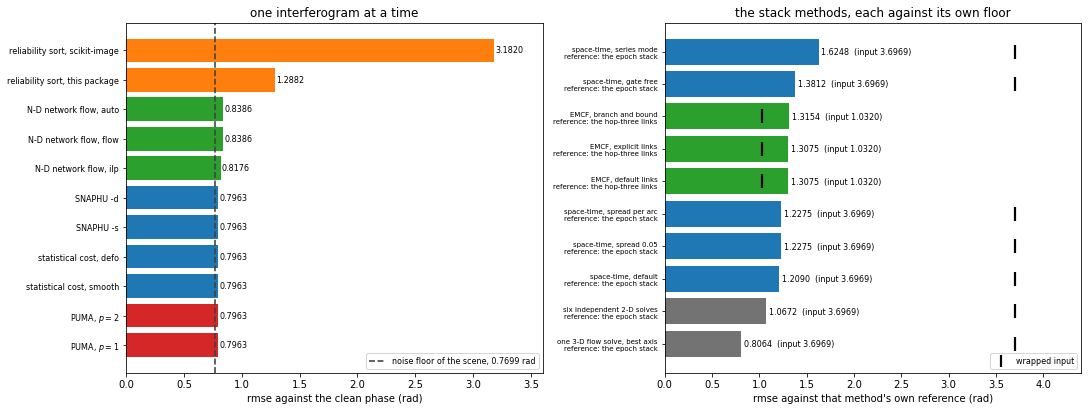


11 single-image runs and 10 multi-observation runs, on a scene of 32 x 32 pixels


In [26]:
FAMILIES = {'PUMA': 'PUMA (graph cut)',
            'statistical': 'statistical cost (SNAPHU)',
            'SNAPHU': 'statistical cost (SNAPHU)',
            'N-D': 'N-D network flow',
            'reliability': 'reliability sort'}


def family(name):
    """The family of single-image method that a result belongs to."""
    return FAMILIES.get(name.split(',')[0].split(' ')[0])


COLORS = {'PUMA (graph cut)': 'tab:red',
          'statistical cost (SNAPHU)': 'tab:blue',
          'N-D network flow': 'tab:green',
          'reliability sort': 'tab:orange'}

single = sorted(((name, value) for name, value in results.items()
                 if family(name) and '3-D' not in name),
                key=lambda item: item[1])

stack_floor = results['wrapped input']
link_floor = rmse(EMCF_INPUT, EMCF_TRUTH)
stacked = [(name, value, stack_floor, 'the epoch stack')
           for name, value in results.items()
           if name.startswith('space-time')]
stacked += [('one 3-D flow solve, best axis',
             results['one 3-D flow solve, best axis'], stack_floor,
             'the epoch stack'),
            ('six independent 2-D solves',
             results['six independent 2-D solves'], stack_floor,
             'the epoch stack')]
stacked += [(name, value, link_floor, 'the hop-three links')
            for name, value in results.items()
            if name.startswith('EMCF')]
stacked.sort(key=lambda item: item[1])

figure, axes = plt.subplots(1, 2, figsize=(15.0, 5.6),
                            constrained_layout=True)

positions = np.arange(len(single))
axes[0].barh(positions, [value for _, value in single],
             color=[COLORS[family(name)] for name, _ in single])
axes[0].set_yticks(positions)
axes[0].set_yticklabels([name for name, _ in single], fontsize=8)
axes[0].axvline(rmse(NOISY, CLEAN), color='0.25', lw=1.6, ls='--',
                label='noise floor of the scene, %.4f rad'
                      % rmse(NOISY, CLEAN))
axes[0].set_xlim(0.0, 3.6)
axes[0].set_xlabel('rmse against the clean phase (rad)')
axes[0].set_title('one interferogram at a time')
axes[0].legend(fontsize=8, loc='lower right')
for position, (_, value) in zip(positions, single):
    axes[0].text(value + 0.01, position, '%.4f' % value, va='center',
                 fontsize=8)

positions = np.arange(len(stacked))
axes[1].barh(positions, [value for _, value, _, _ in stacked],
             color=['tab:blue' if name.startswith('space-time')
                    else 'tab:green' if name.startswith('EMCF')
                    else '0.45' for name, _, _, _ in stacked])
for position, (_, value, floor, _) in zip(positions, stacked):
    axes[1].plot([floor], [position], marker='|', color='black',
                 markersize=14, markeredgewidth=2.2)
    axes[1].text(value + 0.03, position, '%.4f  (input %.4f)'
                 % (value, floor), va='center', fontsize=8)
axes[1].set_yticks(positions)
axes[1].set_yticklabels(['%s\nreference: %s' % (name, reference)
                         for name, _, _, reference in stacked],
                        fontsize=7)
axes[1].set_xlim(0.0, 4.4)
axes[1].set_xlabel('rmse against that method\'s own reference (rad)')
axes[1].set_title('the stack methods, each against its own floor')
axes[1].plot([], [], marker='|', color='black', linestyle='none',
             markersize=12, markeredgewidth=2.2, label='wrapped input')
axes[1].legend(fontsize=8, loc='lower right')
plt.show()

print()
print('%d single-image runs and %d multi-observation runs, on a scene '
      'of %d x %d pixels' % (len(single), len(stacked), ROWS, COLS))


### What the numbers say

**The sorters are the control group, not competitors.** The two orange bars
are the same idea in two implementations: sort the arcs by a reliability
estimate and integrate them in that order. On a noise-free field the sort is
exact, and it still is on the same field once it is wrapped; with noise it
is 3.18 rad, four times the noise floor of the scene and two and a half
times the error of this package's own sort of the same name. Every method
that prices a jump does better, because a sorter can only decide the order
in which to walk, never whether the walk closed a loop. A method that
landed beside the sorters would be a method whose cost term is not being
minimised.

**On one interferogram, the cost model is what matters.** PUMA, the
statistical cost of SNAPHU and the branch-and-bound search of the N-D
module land within 0.022 rad of each other on this scene: 0.7963, 0.7963
and 0.8176 rad. The plain network flow of that module is 0.8386 rad, so the
search is worth 0.021 rad and changes the answer on 5 pixels out of 1024.
All of them are answering the same question -- what should a large change
cost? PUMA's $L^p$ norm spreads a jump across several arcs, the statistical
cost stops charging more once a residual grows past the deformation scale,
and the exact solver refuses to accept the relaxed answer at all. Behind
every one of them is the 0.77 rad noise floor of the scene, which none of
them can go below and none of them reaches.

**The third axis is real.** Six independent two-dimensional solves leave
1.07 rad; one three-dimensional solve over the same six planes leaves 0.81
rad, and which axis is named the third one only moves the third decimal
place (0.8103, 0.8064 and 0.8073 rad for the three choices). The
gain is not that time carries new information about one plane -- it does
not -- but that a wrong turn in one plane shows up as an inconsistency
along the time axis, and the solver has to pay for it.

**A prior is cheaper than a constraint, and this one is weaker.** StaMPS
style space-time unwrapping never builds a three-dimensional network: time
only prices the arcs, and the resulting cost is convex, so the flow it finds
is the global optimum of the objective it states -- a certificate the
graph-cut family cannot offer. On this scene that objective is too weak to
pay off. It reaches 1.2090 rad against the 1.0672 rad of six independent
two-dimensional solves, and against 0.8064 rad for the three-dimensional
flow that does put time on a grid axis. Section 5 traces the reason: six
acquisitions one day apart give the time window almost nothing to average,
so the prior asks for corrections of 0.08 turns on average and the method
inherits the noise of the very epochs it is meant to smooth. The mechanism
is implemented in full and its optimum is exact; whether it wins is a
property of the data rather than of the implementation.

**Redundancy in the stack is used to make the stack consistent, not to
denoise it.** EMCF starts from 1.03 rad of interferometric noise on the
hop-three links and hands back 1.31 rad, so it pays for consistency instead
of buying accuracy: the turns that close the loops of the image and of the
network are not free, and no combination of wrapped differences can recover
the noise that the wrapping destroyed. What the method delivers is a set of
fields that agree with each other, which is the property a deformation time
series actually needs.

### Where this lives in the repository

| section | module | what it implements |
| --- | --- | --- |
| 2 | `src/parvaneh/graph_cut.py` | PUMA: primal-dual graph cuts for an $L^p$ cost |
| 3 | `src/parvaneh/stat_costs.py` | SNAPHU's statistical cost model and its annealed solver |
| 4 | `src/parvaneh/flow_nd.py` | N-D network flow, branch and bound, and slicing |
| 5 | `src/parvaneh/space_time.py` | the StaMPS space-time prior on the arcs of a 2-D grid |
| 6 | `src/parvaneh/emcf.py` | extended minimum cost flow over a temporal network |
| all | `src/parvaneh/graph_flow.py` | the shared engine: cycle bases, dual networks, flow, branch and bound |

Everything is reachable from the command line as well, through
`parvaneh.unwrap`: `--method nd-flow`, `--method stat-costs --costmode
defo`, `--method puma --p 2`, `--method space-time --day ...` and
`--method emcf --links ...` are the entry points, and `--info` prints the
same report objects that this notebook reads.

### References

| reference | what it supplied here |
| --- | --- |
| Herraez, Burton, Lalor and Gdeisat, *Applied Optics* 41(35) (2002) 7437-7446 | the reliability sort, which is the baseline of section 1b |
| Abdul-Rahman, Gdeisat, Burton and Lalor, *Applied Optics* 44(8) (2005) 1447-1454 | the same sort lifted to three dimensions |
| Bioucas-Dias and Valadao, *IEEE TIP* 16(3) (2007) 698-709 | PUMA, section 2, and the $L^p$ cost of section 4 |
| Boykov and Kolmogorov, *IEEE TPAMI* 26(9) (2004) 1124-1137 | the max-flow that the graph cut of section 2 runs on |
| Dinitz, *Soviet Mathematics Doklady* 11 (1970) 1277-1280 | the layered maximum flow with power estimation, the ancestor of the flow in section 2 |
| Boykov, Veksler and Zabih, *IEEE TPAMI* 23(11) (2001) 1222-1239 | the graph construction that turns an $L^p$ cost into a cut, section 2 |
| Kolmogorov and Zabih, *IEEE TPAMI* 26(2) (2004) 147-159 | which functions of binary labels a graph cut can minimise, section 2 |
| Goldstein, Zebker and Werner, *Radio Science* 23(4) (1988) 713-720 | residues and branch cuts, the classical methods behind section 4 |
| Chen and Zebker, *JOSA A* 18(2) (2001) 338-351 | the statistical cost model of section 3 |
| Chen and Zebker, *JOSA A* 17(3) (2000) 401-414 | network approaches, intractability, and the closure phase of section 4 |
| Chen and Zebker, *IEEE TGRS* 40(8) (2002) 1709-1719 | the cost file, the weight floor and the time window of section 5 |
| Costantini, *IEEE TGRS* 36(3) (1998) 813-821 | minimum cost flow as the unwrapping formulation |
| Ghiglia and Pritt, *Two-Dimensional Phase Unwrapping*, Wiley (1998) | the least-squares and multigrid solvers of the package |
| Hooper, Segall and Zebker, *JGR* 112 (2007) B07407 | the space-time prior of section 5 |
| Hooper, *GRL* 35 (2008) L16302 | the small-baseline series mode of section 5 |
| Hooper, Bekaert, Spaans and Arikan, *Tectonophysics* 514-517 (2012) 1-13 | the wider StaMPS processing chain |
| Liu and Pan, *IEEE TGRS* 58(3) (2020) 1857-1867 | three-dimensional minimum cost flow by closure phase, section 4 |
| Pepe and Lanari, *IEEE TGRS* 44(9) (2006) 2374-2383 | the extended minimum cost flow of section 6 |
| Pepe, Euillades, Manunta and Lanari, *IEEE TGRS* 49(10) (2011) 4062-4079 | EMCF as a processing chain, and the hop-three network |
| Huangfu and Hall, *Math. Prog. Comp.* 10(1) (2018) 119-142 | the revised simplex that the branch and bound relaxes with |
| `skimage.restoration.unwrap_phase` | the independent baseline of section 1b |
| `isce-framework/snaphu-py` | the wrapper used to run SNAPHU 2.0.6 and check the cost law of section 3 |
| `yoyolicoris/kamui` | a Python reimplementation of PUMA, read for the conventions of section 2 |
| `isce-framework/spurt` | the open implementation behind the network details of sections 5 and 6 |
| `Fei0906/3D-MCF` | three-dimensional minimum cost flow, read for section 4 |
| `bpauld/PhaseUnwrapping` | iteratively reweighted least squares, the robust alternative not implemented here |

The implementations in this package are written from the papers and, for
the network details, from the published open-source implementations of the
same methods. None of them is copied, translated or called at run time,
with one exception that the notebook states where it happens: section 3
runs the real `snaphu` binary if it is installed, to check the cost law
against the program that defines it. Everything else was read to fix the
conventions that a paper does not state, such as the sign of a residue, the
order of the arcs, the units of a variance and the exact form of a cost
law. The same references, with line-level notes, are in
`docs/algorithms.md` and `docs/references.md`.

Where the code came from and where the papers are:

* <https://scikit-image.org/docs/stable/auto_examples/filters/plot_phase_unwrap.html>
  -- the gallery example that is the baseline of section 1b.
* <https://github.com/isce-framework/snaphu-py> -- the Python interface to
  SNAPHU, and the source of the command line used in section 3.
* <https://github.com/yoyolicoris/kamui> -- PUMA in Python.
* <https://github.com/isce-framework/spurt> -- spatial and temporal
  unwrapping for InSAR time series.
* <https://github.com/Fei0906/3D-MCF> -- three-dimensional minimum cost
  flow.
* <https://github.com/bpauld/PhaseUnwrapping> -- iteratively reweighted
  least squares.
